-> /home/claude/repo/assets/c2c_schematic_capture_point.png


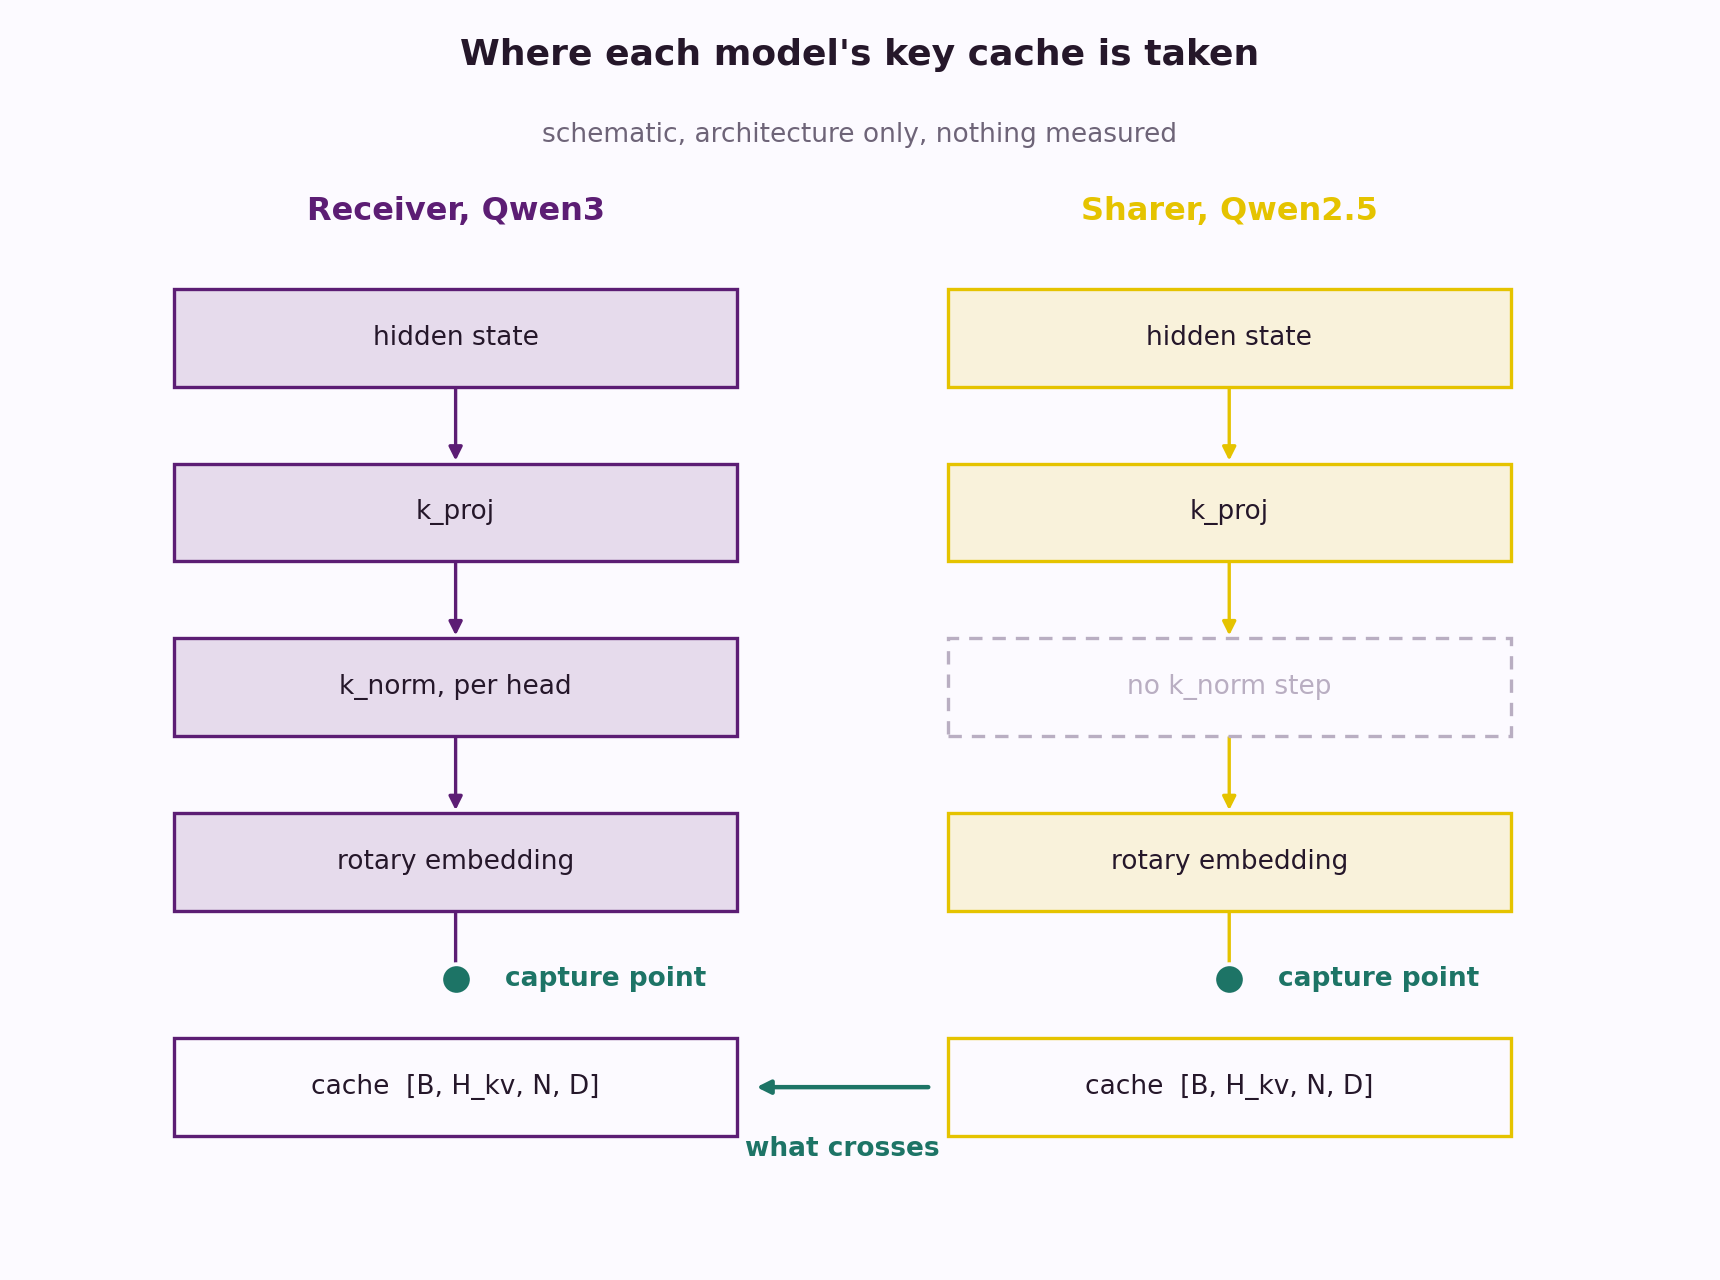

In [1]:
"""Schematic: where in the attention path each model's cache is taken.

No file is read and no number is measured, which is what the
`c2c_schematic_` prefix in the filename declares. The Receiver's key cache is
taken after `k_norm` and after the rotary embedding; the Sharer's is taken
after the rotary embedding alone, because it has no `k_norm` step to pass
through. The missing step is drawn as an empty slot rather than omitted, so
the asymmetry is a fact about the diagram.

Self-contained: run the whole cell. Writes assets/c2c_schematic_capture_point.png
and displays it inline.
"""

import os

import matplotlib.pyplot as plt

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_schematic_capture_point.png")

DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def _box(ax, x, y, w, h, label, face, edge, style="solid", fontsize=9.5,
         textcolor=None):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=face, edgecolor=edge,
                               linewidth=1.2, linestyle=style, zorder=2))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center",
            fontsize=fontsize, color=textcolor or TEXT_COLOR, zorder=3)


def _arrow(ax, x, y0, y1, color):
    ax.annotate("", xy=(x, y1), xytext=(x, y0),
                arrowprops=dict(arrowstyle="-|>", color=color, linewidth=1.2,
                                shrinkA=0, shrinkB=0), zorder=1)


def build_schematic(output_path: str = OUTPUT_PATH) -> None:
    fig, ax = plt.subplots(figsize=(8.6, 6.4), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.86, bottom=0.05, left=0.04, right=0.96)
    ax.set_facecolor(BG_COLOR)

    columns = [
        {
            "x": 0.6, "colour": PRIMARY,
            "title": "Receiver, Qwen3",
            "steps": ["hidden state", "k_proj", "k_norm, per head", "rotary embedding"],
            "present": [True, True, True, True],
            "cache": "cache  [B, H_kv, N, D]",
        },
        {
            "x": 5.0, "colour": SECONDARY,
            "title": "Sharer, Qwen2.5",
            "steps": ["hidden state", "k_proj", "no k_norm step", "rotary embedding"],
            "present": [True, True, False, True],
            "cache": "cache  [B, H_kv, N, D]",
        },
    ]

    box_w, box_h, gap = 3.2, 0.66, 0.52
    top_y = 4.6

    for col in columns:
        x, colour = col["x"], col["colour"]
        ax.text(x + box_w / 2, top_y + box_h + 0.42, col["title"], ha="center",
                va="bottom", fontsize=11.5, fontweight="bold", color=colour)

        y = top_y
        for label, present in zip(col["steps"], col["present"]):
            if present:
                _box(ax, x, y, box_w, box_h, label,
                     face=_mix(colour, BG_COLOR, 0.86), edge=colour)
            else:
                _box(ax, x, y, box_w, box_h, label,
                     face=BG_COLOR, edge=MUTED, style=(0, (4, 3)),
                     textcolor=MUTED)
            _arrow(ax, x + box_w / 2, y, y - gap + 0.02, colour)
            y -= box_h + gap

        ax.plot([x + box_w / 2], [y + box_h + 0.06], marker="o", markersize=11,
                markerfacecolor=TERTIARY, markeredgecolor=BG_COLOR,
                markeredgewidth=1.4, zorder=4)
        ax.text(x + box_w / 2 + 0.28, y + box_h + 0.06, "capture point",
                ha="left", va="center", fontsize=9.5, color=TERTIARY,
                fontweight="bold")

        _box(ax, x, y - 0.34, box_w, box_h, col["cache"],
             face=BG_COLOR, edge=colour, fontsize=9.5)

    ax.annotate(
        "",
        xy=(3.88, -0.13), xytext=(4.92, -0.13),
        arrowprops=dict(arrowstyle="-|>", color=TERTIARY, linewidth=1.6),
    )
    ax.text(4.4, -0.46, "what crosses", ha="center", va="top", fontsize=9.5,
            color=TERTIARY, fontweight="bold")

    ax.set_xlim(0, 9.0)
    ax.set_ylim(-1.0, 6.0)
    ax.axis("off")

    fig.suptitle("Where each model's key cache is taken",
                 color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.97)
    fig.text(0.5, 0.905,
             "schematic, architecture only, nothing measured",
             ha="center", va="top", fontsize=9.5, color="#6E6478")

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    print(f"-> {output_path}")


def main() -> None:
    build_schematic()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

-> /home/claude/repo/assets/c2c_schematic_key_value_asymmetry.png


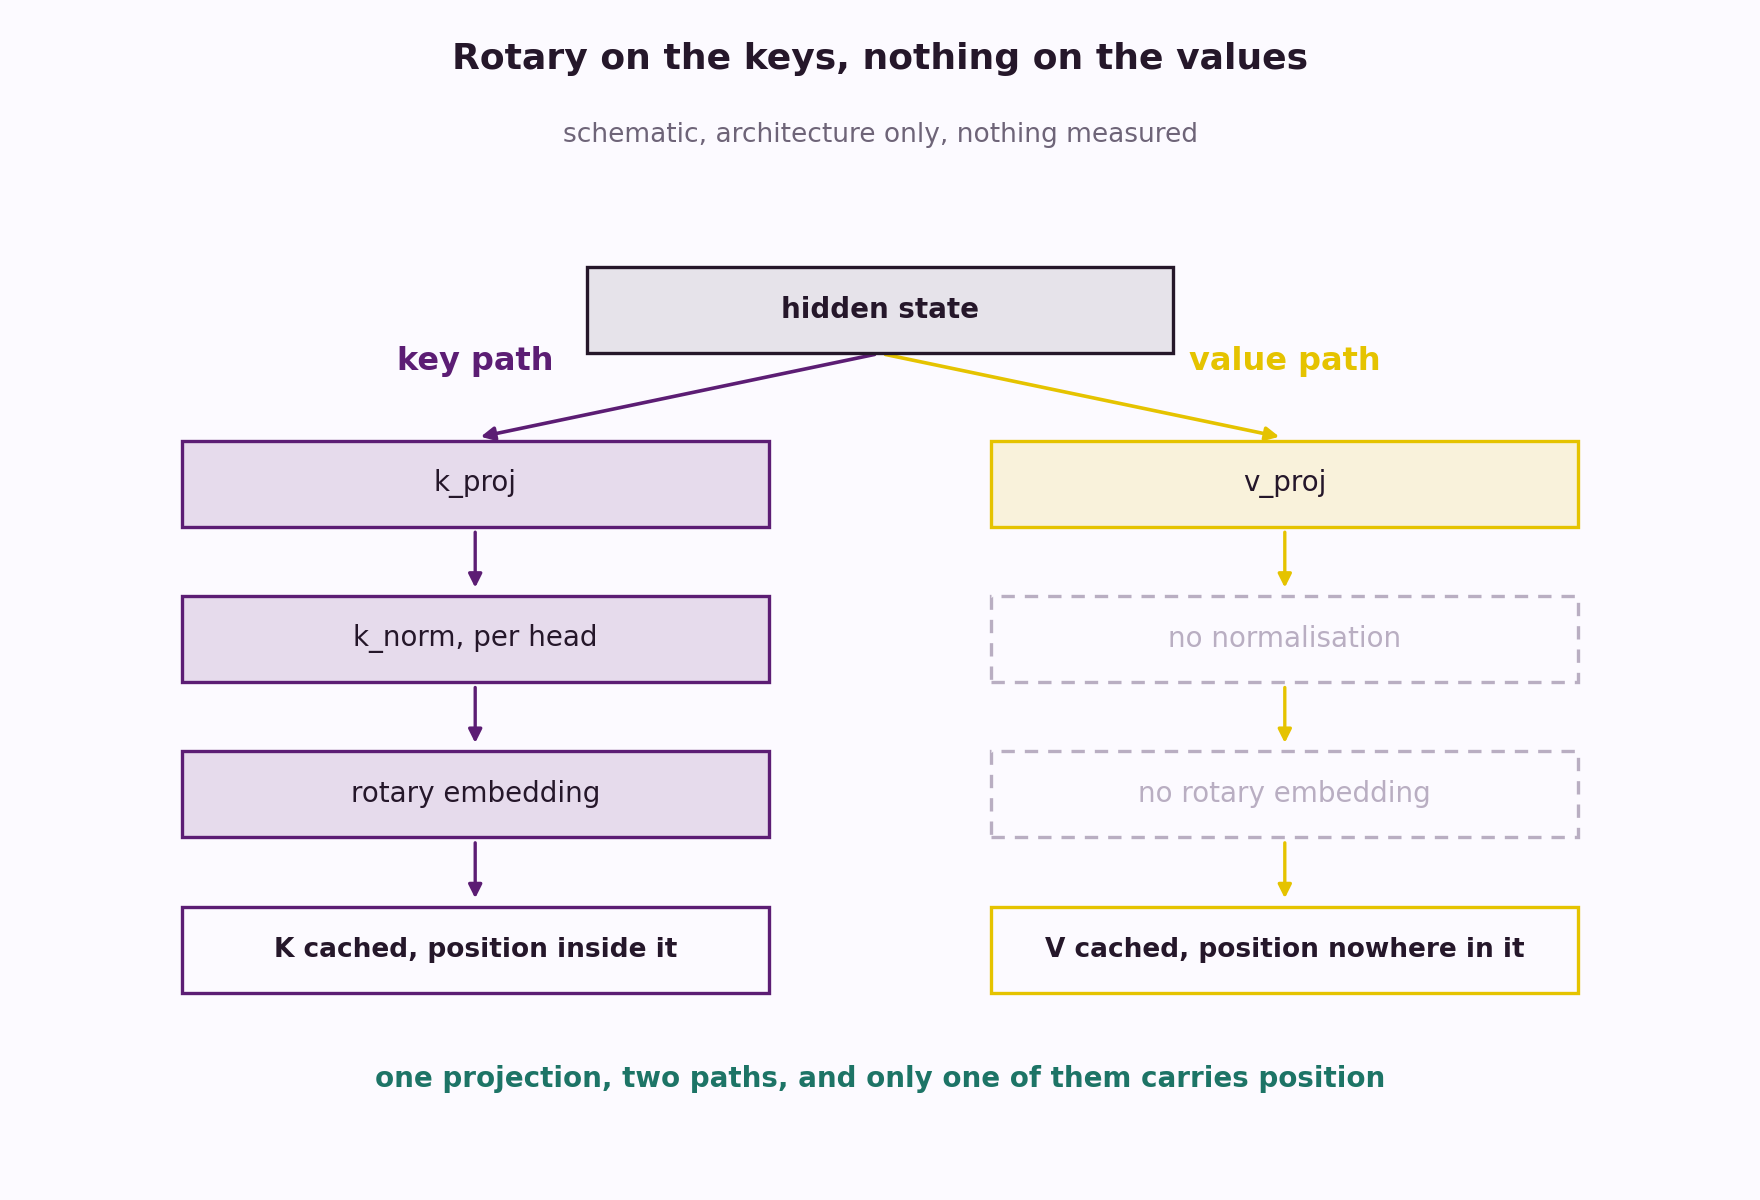

In [2]:
"""Schematic: the rotary embedding applied to keys and not to values.

Two paths leave the same hidden state. The key path passes through a
normalisation and a rotation before it is cached; the value path passes
through neither. Drawing both from one origin makes the asymmetry a property
of the picture rather than a sentence underneath it, which matters because
every later claim about keys behaving differently from values rests on this
one structural difference.

No file is read, which is what the `c2c_schematic_` prefix declares.

Self-contained: run the whole cell. Writes
assets/c2c_schematic_key_value_asymmetry.png and displays it inline.
"""

import os

import matplotlib.pyplot as plt

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_schematic_key_value_asymmetry.png")

DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def _box(ax, x, y, w, h, label, face, edge, style="solid", fontsize=10,
         textcolor=None, weight="normal"):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=face, edgecolor=edge,
                               linewidth=1.2, linestyle=style, zorder=2))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center",
            fontsize=fontsize, color=textcolor or TEXT_COLOR, zorder=3,
            fontweight=weight)


def build_schematic(output_path: str = OUTPUT_PATH) -> None:
    fig, ax = plt.subplots(figsize=(8.8, 6.0), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.85, bottom=0.04, left=0.04, right=0.96)
    ax.set_facecolor(BG_COLOR)

    box_w, box_h, gap = 2.9, 0.62, 0.5
    top_y = 3.85

    _box(ax, 2.55, top_y + 1.25, box_w, box_h, "hidden state",
         face=_mix(TEXT_COLOR, BG_COLOR, 0.9), edge=TEXT_COLOR, weight="bold")

    paths = [
        {
            "x": 0.55, "colour": PRIMARY, "title": "key path",
            "steps": [("k_proj", True), ("k_norm, per head", True),
                      ("rotary embedding", True)],
            "cache": "K cached, position inside it",
        },
        {
            "x": 4.55, "colour": SECONDARY, "title": "value path",
            "steps": [("v_proj", True), ("no normalisation", False),
                      ("no rotary embedding", False)],
            "cache": "V cached, position nowhere in it",
        },
    ]

    for path in paths:
        x, colour = path["x"], path["colour"]
        ax.annotate("", xy=(x + box_w / 2, top_y + box_h + 0.02),
                    xytext=(4.0, top_y + 1.25),
                    arrowprops=dict(arrowstyle="-|>", color=colour, linewidth=1.3,
                                    connectionstyle="arc3,rad=0.0"), zorder=1)
        ax.text(x + box_w / 2, top_y + box_h + 0.46, path["title"], ha="center",
                va="bottom", fontsize=11.5, fontweight="bold", color=colour)

        y = top_y
        for label, present in path["steps"]:
            if present:
                _box(ax, x, y, box_w, box_h, label,
                     face=_mix(colour, BG_COLOR, 0.86), edge=colour)
            else:
                _box(ax, x, y, box_w, box_h, label, face=BG_COLOR, edge=MUTED,
                     style=(0, (4, 3)), textcolor=MUTED)
            ax.annotate("", xy=(x + box_w / 2, y - gap + 0.02),
                        xytext=(x + box_w / 2, y),
                        arrowprops=dict(arrowstyle="-|>", color=colour,
                                        linewidth=1.2), zorder=1)
            y -= box_h + gap

        _box(ax, x, y, box_w, box_h, path["cache"], face=BG_COLOR, edge=colour,
             fontsize=9.5, weight="bold")

    ax.text(4.0, y - 0.52,
            "one projection, two paths, and only one of them carries position",
            ha="center", va="top", fontsize=10, color=TERTIARY, fontweight="bold")

    ax.set_xlim(0, 8.0)
    ax.set_ylim(y - 1.15, top_y + 2.5)
    ax.axis("off")

    fig.suptitle("Rotary on the keys, nothing on the values",
                 color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.965)
    fig.text(0.5, 0.898, "schematic, architecture only, nothing measured",
             ha="center", va="top", fontsize=9.5, color="#6E6478")

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    print(f"-> {output_path}")


def main() -> None:
    build_schematic()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

sharer 128 + receiver 1024 = 1152, sharer share 0.1111 (1/9.00)
-> /home/claude/repo/assets/c2c_channel_widths.png


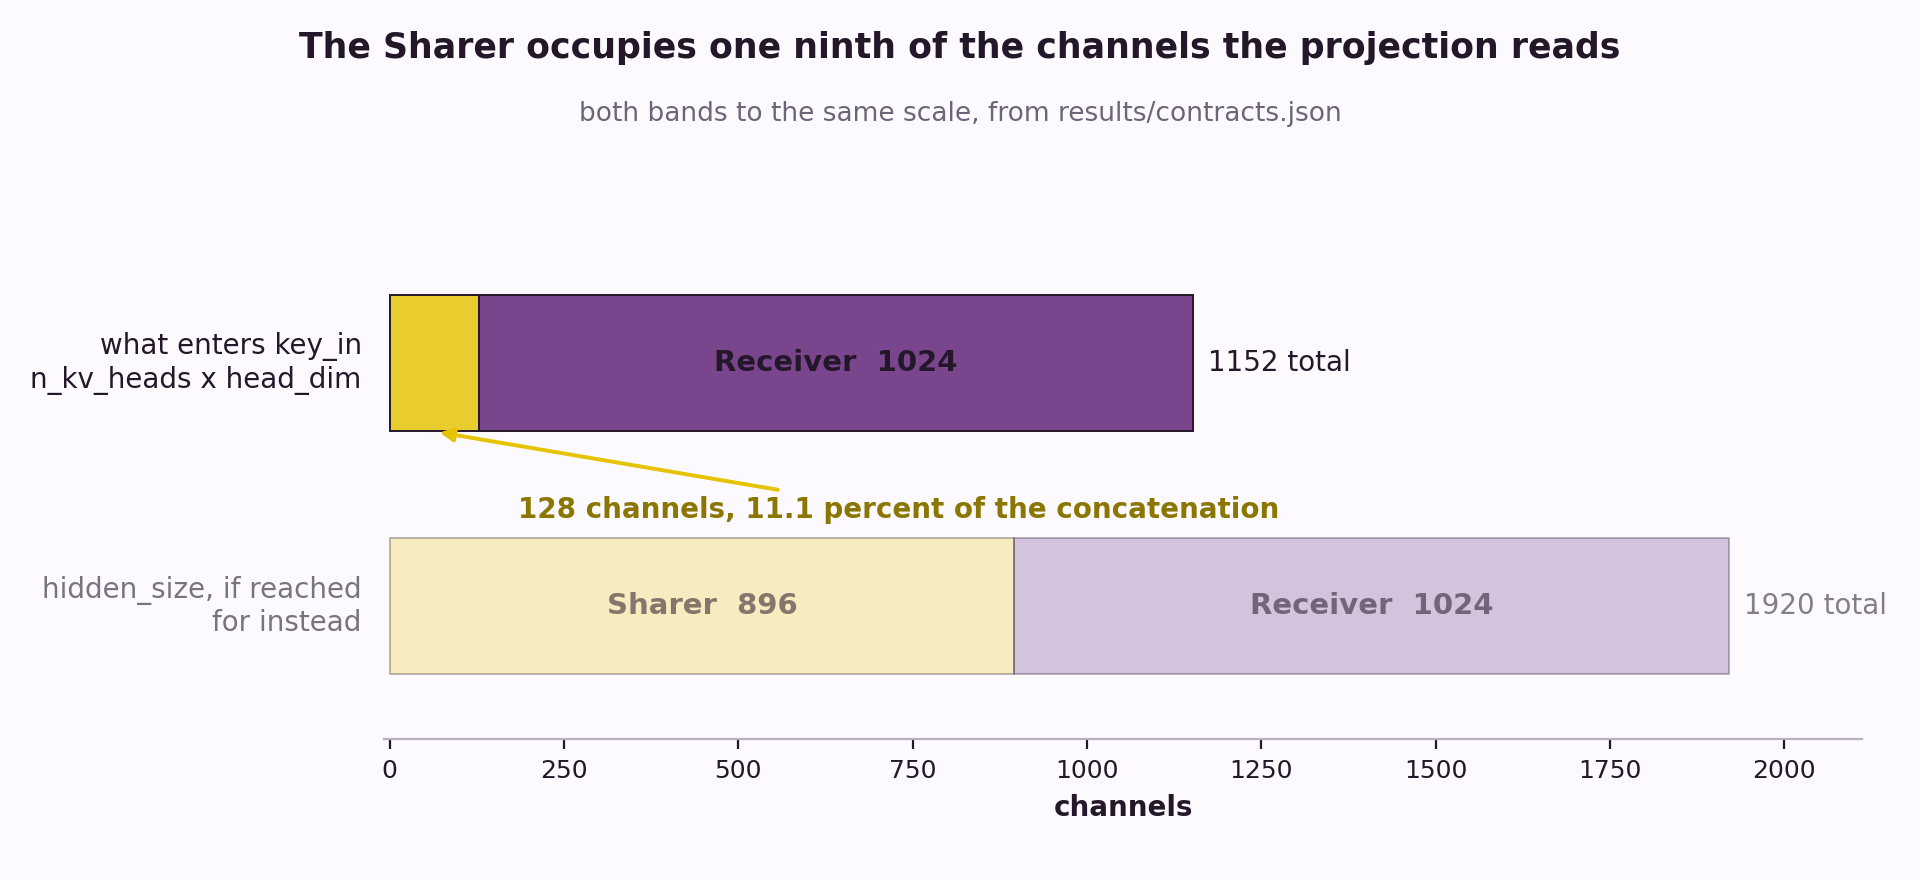

In [3]:
"""The two contributions entering the projection, drawn to scale.

Reads results/contracts.json. The concatenation that feeds `key_in` is the
Sharer's `kv_width` beside the Receiver's, and both are `n_kv_heads x
head_dim` rather than `hidden_size`. The second band is the width the same
figure would have if `hidden_size` had been reached for instead, and it is
drawn to the same scale so the size of that mistake is a length on the page
rather than a warning underneath one.

Self-contained: run the whole cell. Writes assets/c2c_channel_widths.png and
displays it inline.
"""

import json
import os

import matplotlib.pyplot as plt

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

CONTRACTS_PATH = os.path.join(_THIS_DIR, "results", "contracts.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_channel_widths.png")

DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(path: str = CONTRACTS_PATH) -> dict:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/capture_contracts.py first")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def build_channel_widths(contract: dict, output_path: str = OUTPUT_PATH) -> tuple:
    widths = contract["concat_widths"]
    sharer_kv = widths["sharer_kv_width"]
    receiver_kv = widths["receiver_kv_width"]
    concat = widths["concat_width"]
    sharer_share = widths["sharer_share"]

    sharer_hidden = contract["sharer"]["hidden_size"]
    receiver_hidden = contract["receiver"]["hidden_size"]
    hidden_concat = sharer_hidden + receiver_hidden

    fig, ax = plt.subplots(figsize=(9.6, 4.4), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.76, bottom=0.16, left=0.20, right=0.97)
    ax.set_facecolor(BG_COLOR)

    bar_h = 0.42
    rows = [
        {
            "y": 1.0,
            "label": "what enters key_in\nn_kv_heads x head_dim",
            "parts": [(sharer_kv, SECONDARY, "Sharer"),
                      (receiver_kv, PRIMARY, "Receiver")],
            "alpha": 1.0,
            "total": concat,
        },
        {
            "y": 0.25,
            "label": "hidden_size, if reached\nfor instead",
            "parts": [(sharer_hidden, SECONDARY, "Sharer"),
                      (receiver_hidden, PRIMARY, "Receiver")],
            "alpha": 0.30,
            "total": hidden_concat,
        },
    ]

    for row in rows:
        left = 0
        for size, colour, name in row["parts"]:
            ax.add_patch(plt.Rectangle((left, row["y"]), size, bar_h,
                                       facecolor=_mix(colour, BG_COLOR, 0.18),
                                       edgecolor=TEXT_COLOR, linewidth=0.7,
                                       alpha=row["alpha"], zorder=2))
            if size / row["total"] > 0.2:
                ax.text(left + size / 2, row["y"] + bar_h / 2, f"{name}  {size}",
                        ha="center", va="center", fontsize=10.5, color=TEXT_COLOR,
                        fontweight="bold", alpha=max(row["alpha"], 0.55), zorder=3)
            left += size
        ax.text(left + 22, row["y"] + bar_h / 2, f"{row['total']} total",
                ha="left", va="center", fontsize=10, color=TEXT_COLOR,
                alpha=max(row["alpha"], 0.55))
        ax.text(-40, row["y"] + bar_h / 2, row["label"], ha="right", va="center",
                fontsize=10, color=TEXT_COLOR, alpha=max(row["alpha"], 0.6))

    ax.annotate(
        f"{sharer_kv} channels, {sharer_share * 100:.1f} percent of the concatenation",
        xy=(sharer_kv / 2, 1.0), xytext=(sharer_kv / 2 + 120, 0.80),
        arrowprops=dict(arrowstyle="-|>", color=SECONDARY, linewidth=1.4),
        fontsize=10, color="#8A7600", fontweight="bold", va="top",
    )

    ax.set_xlim(-8, hidden_concat * 1.10)
    ax.set_ylim(0.05, 1.68)
    ax.set_yticks([])
    ax.set_xlabel("channels", fontsize=10, fontweight="bold", color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)

    fig.suptitle("The Sharer occupies one ninth of the channels the projection reads",
                 color=TEXT_COLOR, fontweight="bold", fontsize=12.5, y=0.965)
    fig.text(0.5, 0.885,
             "both bands to the same scale, from results/contracts.json",
             ha="center", va="top", fontsize=9.5, color="#6E6478")

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return sharer_kv, receiver_kv, concat, sharer_share


def main() -> None:
    contract = load()
    sharer_kv, receiver_kv, concat, share = build_channel_widths(contract)
    print(f"sharer {sharer_kv} + receiver {receiver_kv} = {concat}, "
          f"sharer share {share:.4f} (1/{1 / share:.2f})")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

recomputed nesting deviation 0.000e+00 | file records stride 2, holds True, max_rel_dev 0.0
-> /home/claude/repo/assets/c2c_rope_ladders.png


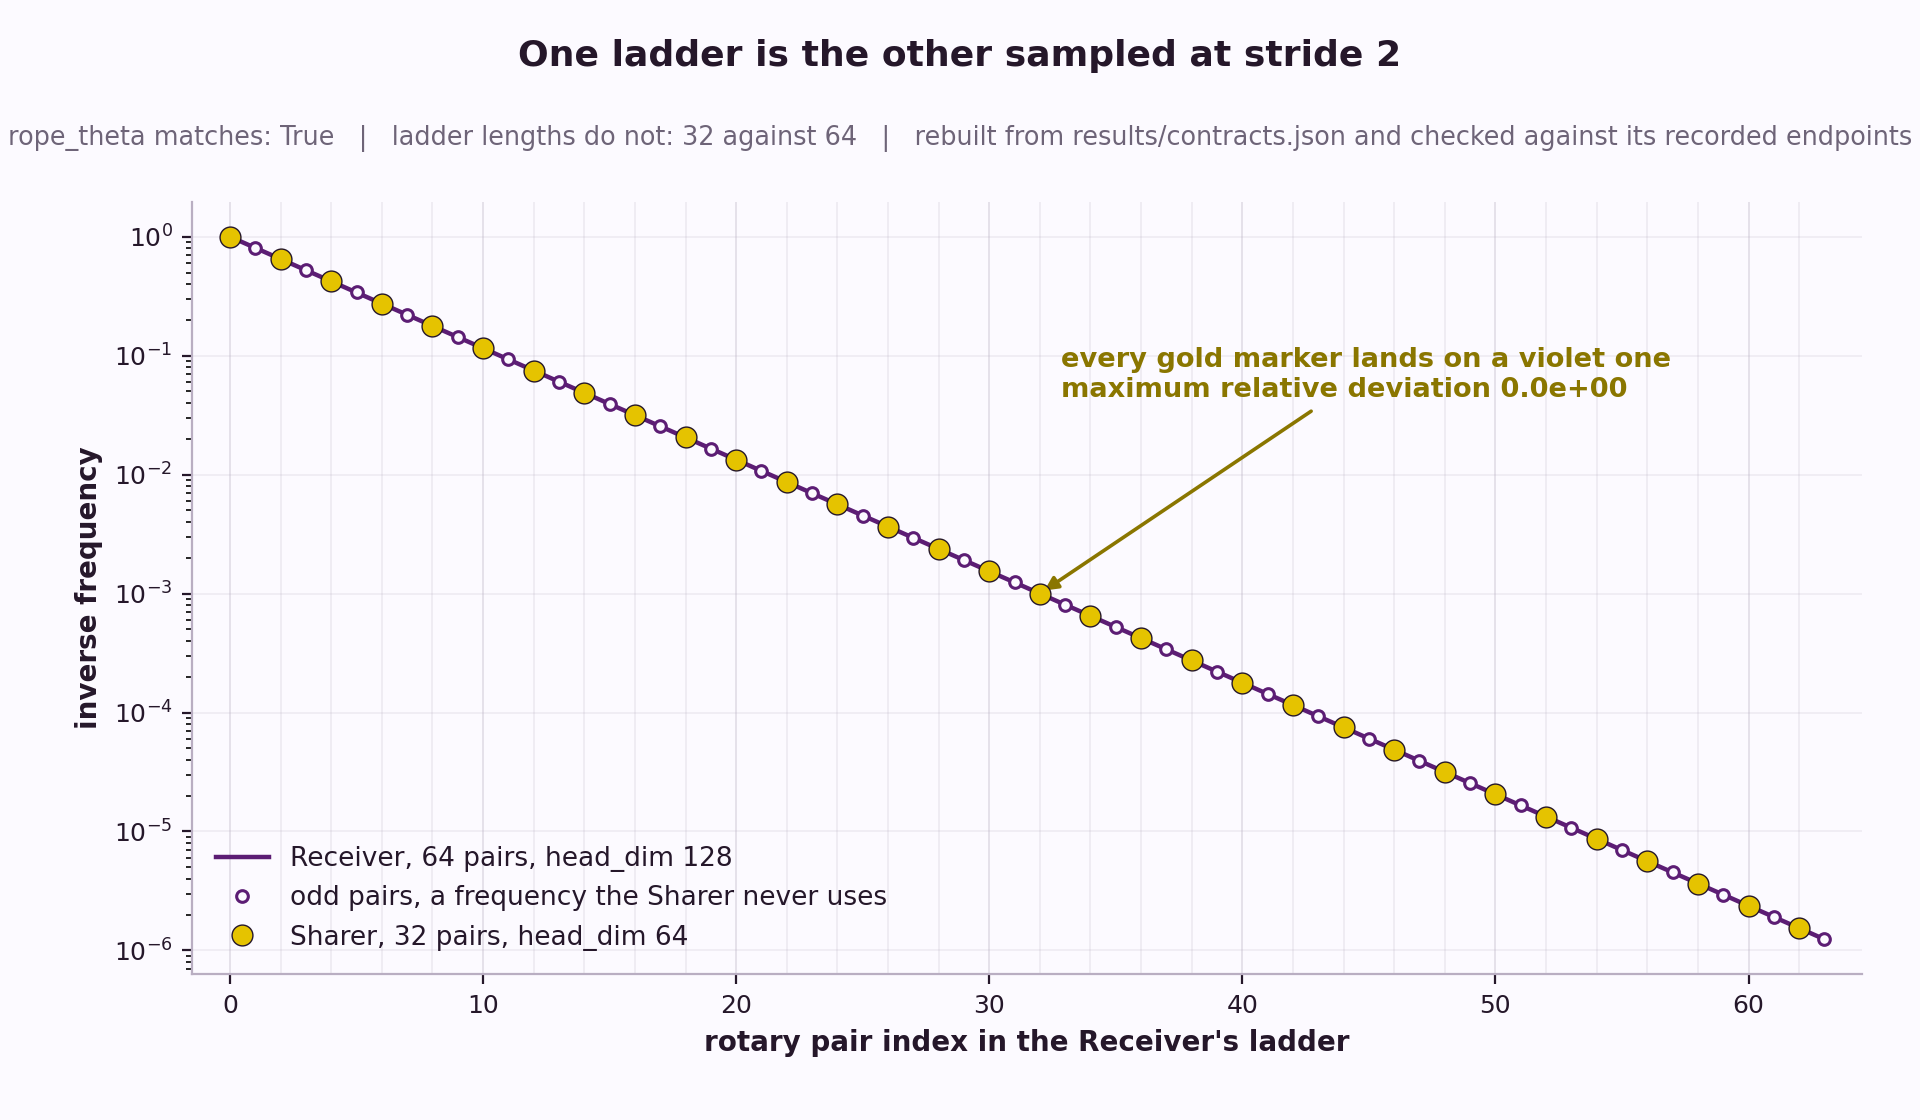

In [4]:
"""Both rotary ladders on one axis, and where one nests inside the other.

Reads results/contracts.json. The `inv_freq` arrays are rebuilt from the
`rope_theta` and `head_dim` the contract recorded, and the rebuild is checked
against the endpoints the contract also recorded before anything is drawn, so
the curve on the page is the file's and not a formula that happens to look
like it.

The x axis is the rotary pair index inside the Receiver's own ladder. Placing
the Sharer's pair j at 2j is the claim the figure makes: the coarse ladder is
the fine one sampled at stride two, so half of the rotation a Receiver key
needs is physically present in a transferred key and half is a frequency the
Sharer never uses.

Self-contained: run the whole cell. Writes assets/c2c_rope_ladders.png and
displays it inline.
"""

import json
import os

import numpy as np
import matplotlib.pyplot as plt

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

CONTRACTS_PATH = os.path.join(_THIS_DIR, "results", "contracts.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_rope_ladders.png")

RECONSTRUCTION_TOLERANCE = 1e-12
DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"
GOLD_INK = "#8A7600"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(path: str = CONTRACTS_PATH) -> dict:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/capture_contracts.py first")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def _inv_freq(contract: dict, model: str) -> np.ndarray:
    theta = float(contract["config_provenance"][model]["raw_values"]["rope_theta"])
    head_dim = int(contract[model]["head_dim"])
    freqs = 1.0 / (theta ** (np.arange(0, head_dim, 2, dtype=np.float64) / head_dim))

    recorded_n = contract["rope_comparison"]["n_inv_freq"][model]
    recorded_span = contract["rope_comparison"]["range_span"][model]
    if len(freqs) != recorded_n:
        raise SystemExit(f"{model}: rebuilt {len(freqs)} frequencies, file says {recorded_n}")
    for rebuilt, recorded in zip((freqs[0], freqs[-1]), recorded_span):
        if abs(rebuilt - recorded) > RECONSTRUCTION_TOLERANCE * max(1.0, abs(recorded)):
            raise SystemExit(f"{model}: rebuilt endpoint {rebuilt} against recorded {recorded}")
    return freqs


def build_rope_ladders(contract: dict, output_path: str = OUTPUT_PATH) -> tuple:
    sharer = _inv_freq(contract, "sharer")
    receiver = _inv_freq(contract, "receiver")
    nesting = contract["rope_comparison"]["nesting"]
    stride = int(nesting["stride"])

    sampled = receiver[::stride]
    deviation = float(np.max(np.abs(sharer - sampled) / np.abs(sampled)))

    x_receiver = np.arange(len(receiver))
    x_sharer = np.arange(len(sharer)) * stride

    fig, ax = plt.subplots(figsize=(9.6, 5.6), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.82, bottom=0.13, left=0.10, right=0.97)
    ax.set_facecolor(BG_COLOR)

    for x in x_sharer:
        ax.axvline(x, color=MUTED, alpha=0.22, linewidth=0.6, zorder=0)

    ax.plot(x_receiver, receiver, color=PRIMARY, linewidth=1.6, zorder=3,
            label=f"Receiver, {len(receiver)} pairs, head_dim {contract['receiver']['head_dim']}")
    ax.plot(x_receiver[1::2], receiver[1::2], linestyle="none", marker="o",
            markersize=4.2, markerfacecolor=BG_COLOR, markeredgecolor=PRIMARY,
            markeredgewidth=1.1, zorder=4,
            label="odd pairs, a frequency the Sharer never uses")
    ax.plot(x_sharer, sharer, linestyle="none", marker="o", markersize=7.5,
            markerfacecolor=SECONDARY, markeredgecolor=TEXT_COLOR,
            markeredgewidth=0.5, zorder=5,
            label=f"Sharer, {len(sharer)} pairs, head_dim {contract['sharer']['head_dim']}")

    ax.set_yscale("log")
    ax.set_xlabel("rotary pair index in the Receiver's ladder", fontsize=10,
                  fontweight="bold", color=TEXT_COLOR)
    ax.set_ylabel("inverse frequency", fontsize=10, fontweight="bold",
                  color=TEXT_COLOR)
    ax.set_xlim(-1.5, len(receiver) + 0.5)
    ax.grid(True, color=MUTED, alpha=0.20, linewidth=0.6)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED)

    legend = ax.legend(loc="lower left", frameon=False, fontsize=9.5)
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)

    theta_match = contract["rope_comparison"]["theta_match"]
    ax.annotate(
        f"every gold marker lands on a violet one\nmaximum relative deviation {deviation:.1e}",
        xy=(x_sharer[len(x_sharer) // 2], sharer[len(sharer) // 2]),
        xytext=(0.52, 0.74), textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-|>", color=GOLD_INK, linewidth=1.3),
        fontsize=9.8, color=GOLD_INK, fontweight="bold", va="bottom",
    )

    fig.suptitle(
        f"One ladder is the other sampled at stride {stride}",
        color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.965,
    )
    fig.text(0.5, 0.888,
             f"rope_theta matches: {theta_match}   |   "
             f"ladder lengths do not: {len(sharer)} against {len(receiver)}   |   "
             "rebuilt from results/contracts.json and checked against its recorded endpoints",
             ha="center", va="top", fontsize=9.2, color="#6E6478")

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return deviation, nesting


def main() -> None:
    contract = load()
    deviation, nesting = build_rope_ladders(contract)
    print(f"recomputed nesting deviation {deviation:.3e} | file records "
          f"stride {nesting['stride']}, holds {nesting['holds']}, "
          f"max_rel_dev {nesting['max_rel_dev']}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

24 pairs, terminal target 27 <- source 23, unpaired targets [0, 1, 2, 3]
-> /home/claude/repo/assets/c2c_layer_mapping.png


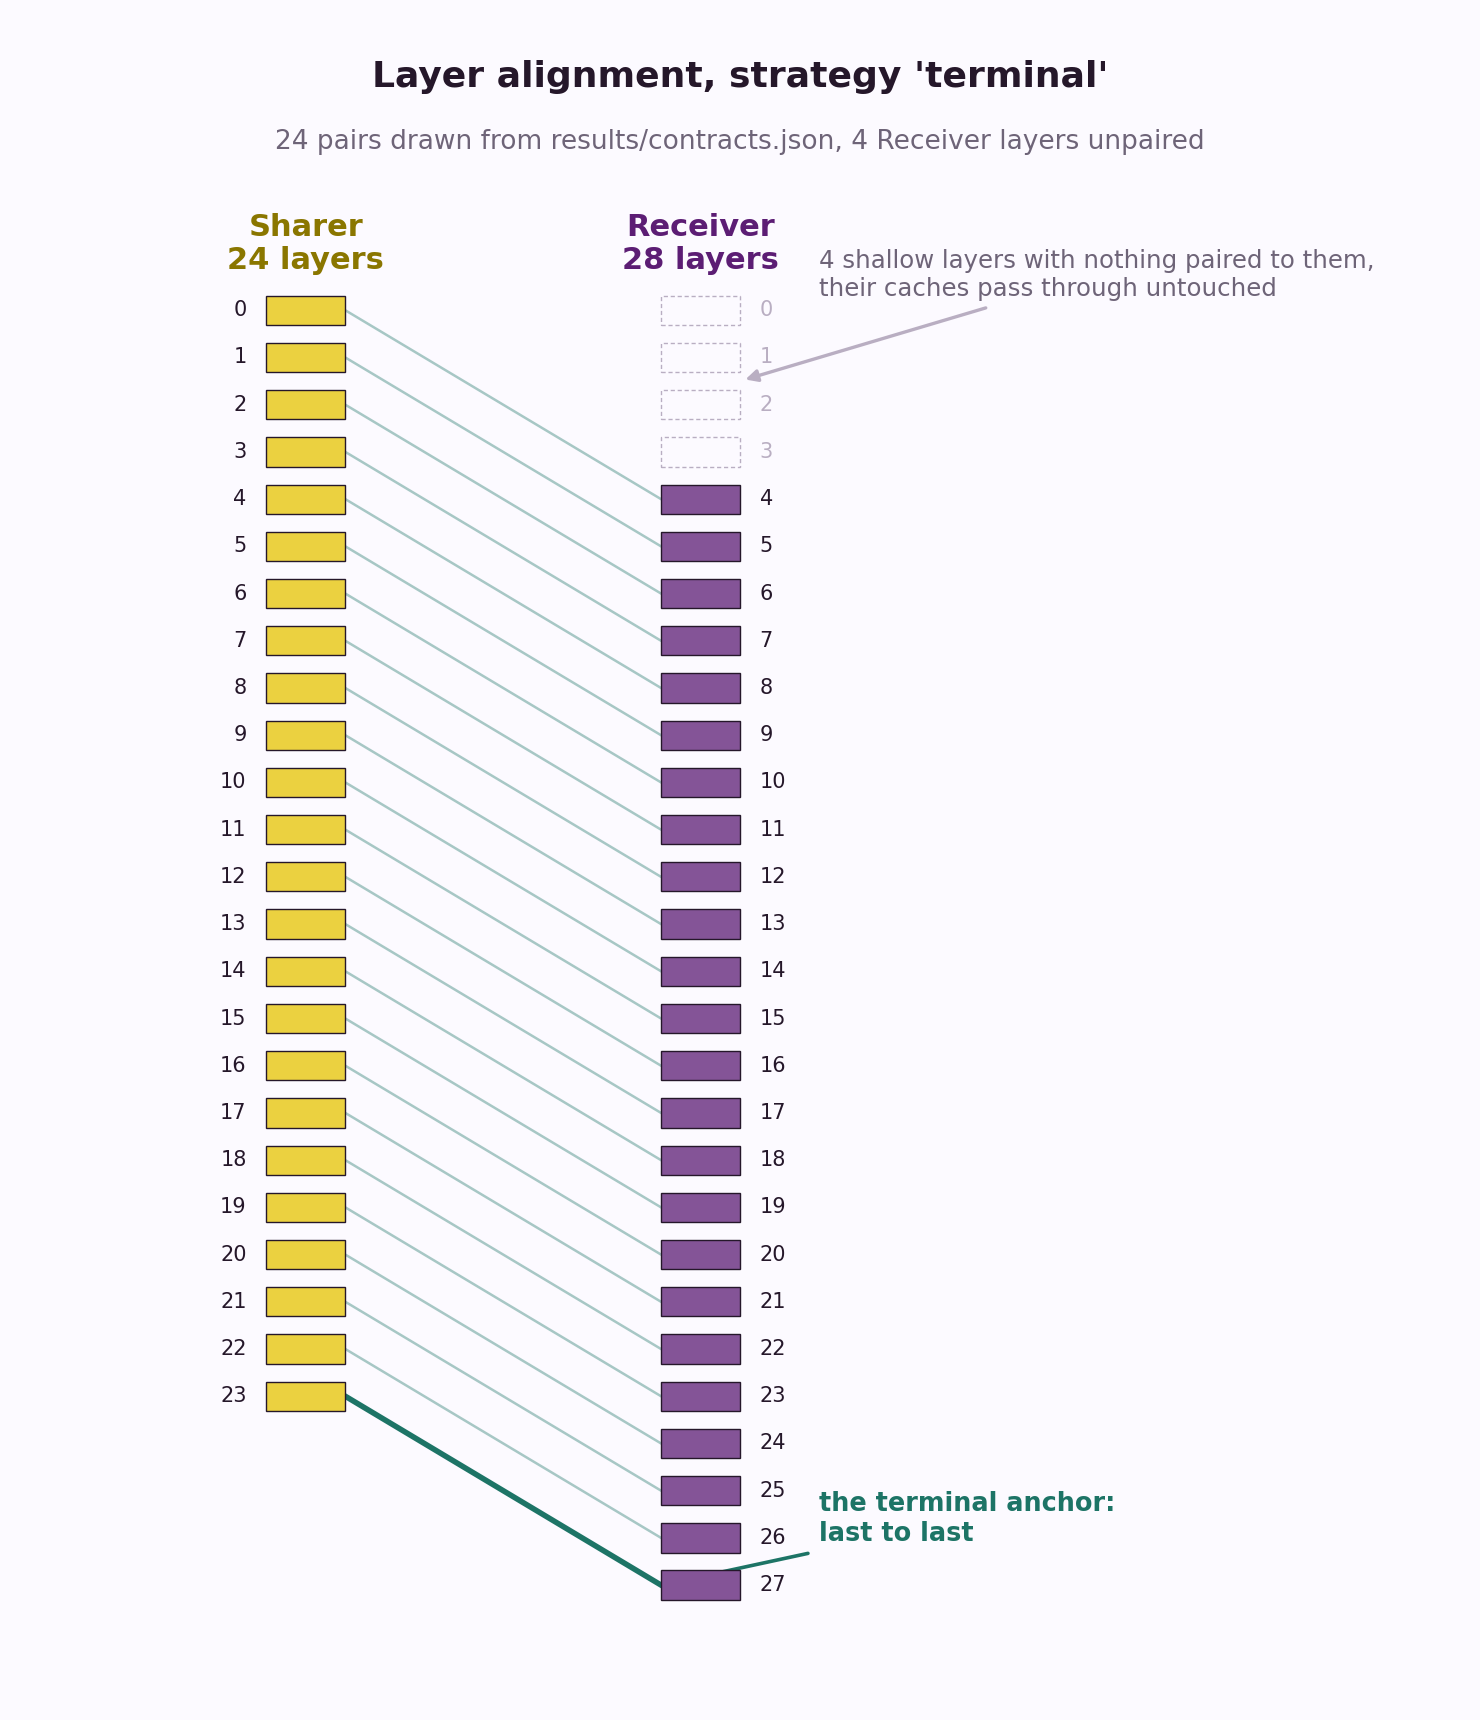

In [5]:
"""The 24 to 28 terminal pairing, with the unpaired shallow layers legible.

Reads results/contracts.json. Every connection drawn is a row of
`layer_alignment.pairs`; nothing is inferred from the counts. The four
Receiver layers the alignment leaves out are drawn in the same column rather
than omitted, because their caches pass through every build in this
repository untouched, which makes every result here a partial intervention by
construction.

Self-contained: run the whole cell. Writes assets/c2c_layer_mapping.png and
displays it inline.
"""

import json
import os

import matplotlib.pyplot as plt

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

CONTRACTS_PATH = os.path.join(_THIS_DIR, "results", "contracts.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_layer_mapping.png")

DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(path: str = CONTRACTS_PATH) -> dict:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/capture_contracts.py first")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def build_layer_mapping(contract: dict, output_path: str = OUTPUT_PATH) -> tuple:
    alignment = contract["layer_alignment"]
    pairs = [tuple(p) for p in alignment["pairs"]]
    unpaired = list(alignment["unpaired_targets"])
    n_source = contract["layer_counts"]["n_source_layers"]
    n_target = contract["layer_counts"]["n_target_layers"]
    strategy = alignment["strategy"]

    x_source, x_target = 0.0, 1.0
    box_w, box_h = 0.20, 0.62

    fig, ax = plt.subplots(figsize=(7.4, 8.6), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.88, bottom=0.04, left=0.06, right=0.94)
    ax.set_facecolor(BG_COLOR)

    terminal = max(pairs, key=lambda p: p[0])

    for target, source in pairs:
        is_terminal = (target, source) == terminal
        ax.plot([x_source + box_w / 2, x_target - box_w / 2], [-source, -target],
                color=TERTIARY if is_terminal else _mix(TERTIARY, BG_COLOR, 0.62),
                linewidth=2.0 if is_terminal else 0.9,
                zorder=3 if is_terminal else 1)

    for source in range(n_source):
        ax.add_patch(plt.Rectangle((x_source - box_w / 2, -source - box_h / 2),
                                   box_w, box_h,
                                   facecolor=_mix(SECONDARY, BG_COLOR, 0.25),
                                   edgecolor=TEXT_COLOR, linewidth=0.5, zorder=4))
        ax.text(x_source - box_w / 2 - 0.05, -source, str(source), ha="right",
                va="center", fontsize=7.5, color=TEXT_COLOR)

    for target in range(n_target):
        is_unpaired = target in unpaired
        ax.add_patch(plt.Rectangle((x_target - box_w / 2, -target - box_h / 2),
                                   box_w, box_h,
                                   facecolor=BG_COLOR if is_unpaired
                                   else _mix(PRIMARY, BG_COLOR, 0.25),
                                   edgecolor=MUTED if is_unpaired else TEXT_COLOR,
                                   linewidth=0.5,
                                   linestyle=(0, (3, 2)) if is_unpaired else "solid",
                                   zorder=4))
        ax.text(x_target + box_w / 2 + 0.05, -target, str(target), ha="left",
                va="center", fontsize=7.5,
                color=MUTED if is_unpaired else TEXT_COLOR)

    ax.text(x_source, 1.4, f"Sharer\n{n_source} layers", ha="center", va="center",
            fontsize=11, fontweight="bold", color="#8A7600")
    ax.text(x_target, 1.4, f"Receiver\n{n_target} layers", ha="center", va="center",
            fontsize=11, fontweight="bold", color=PRIMARY)

    ax.annotate(
        f"{len(unpaired)} shallow layers with nothing paired to them,\n"
        "their caches pass through untouched",
        xy=(x_target + box_w / 2, -(unpaired[-1] + unpaired[0]) / 2),
        xytext=(x_target + 0.30, 0.75),
        arrowprops=dict(arrowstyle="-|>", color=MUTED, linewidth=1.2),
        fontsize=8.8, color="#6E6478", va="center", ha="left",
    )
    ax.annotate(
        "the terminal anchor:\nlast to last",
        xy=(x_target - box_w / 2, -terminal[0]),
        xytext=(x_target + 0.30, -n_target + 2.4),
        arrowprops=dict(arrowstyle="-|>", color=TERTIARY, linewidth=1.3),
        fontsize=9.2, color=TERTIARY, fontweight="bold", va="center", ha="left",
    )

    ax.set_xlim(-0.55, 2.75)
    ax.set_ylim(-n_target - 0.4, 2.2)
    ax.axis("off")

    fig.suptitle(f"Layer alignment, strategy '{strategy}'",
                 color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.965)
    fig.text(0.5, 0.925,
             f"{len(pairs)} pairs drawn from results/contracts.json, "
             f"{len(unpaired)} Receiver layers unpaired",
             ha="center", va="top", fontsize=9.5, color="#6E6478")

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return pairs, unpaired, terminal


def main() -> None:
    contract = load()
    pairs, unpaired, terminal = build_layer_mapping(contract)
    print(f"{len(pairs)} pairs, terminal target {terminal[0]} <- source {terminal[1]}, "
          f"unpaired targets {unpaired}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

baseline against itself: 0 absolute, 0 of scale
its own cache handed back: 0 absolute, 0 of scale
corrupted at matched norm: 27.8182 absolute, 1.33935 of scale
-> /home/claude/repo/assets/c2c_substrate_triptych.png


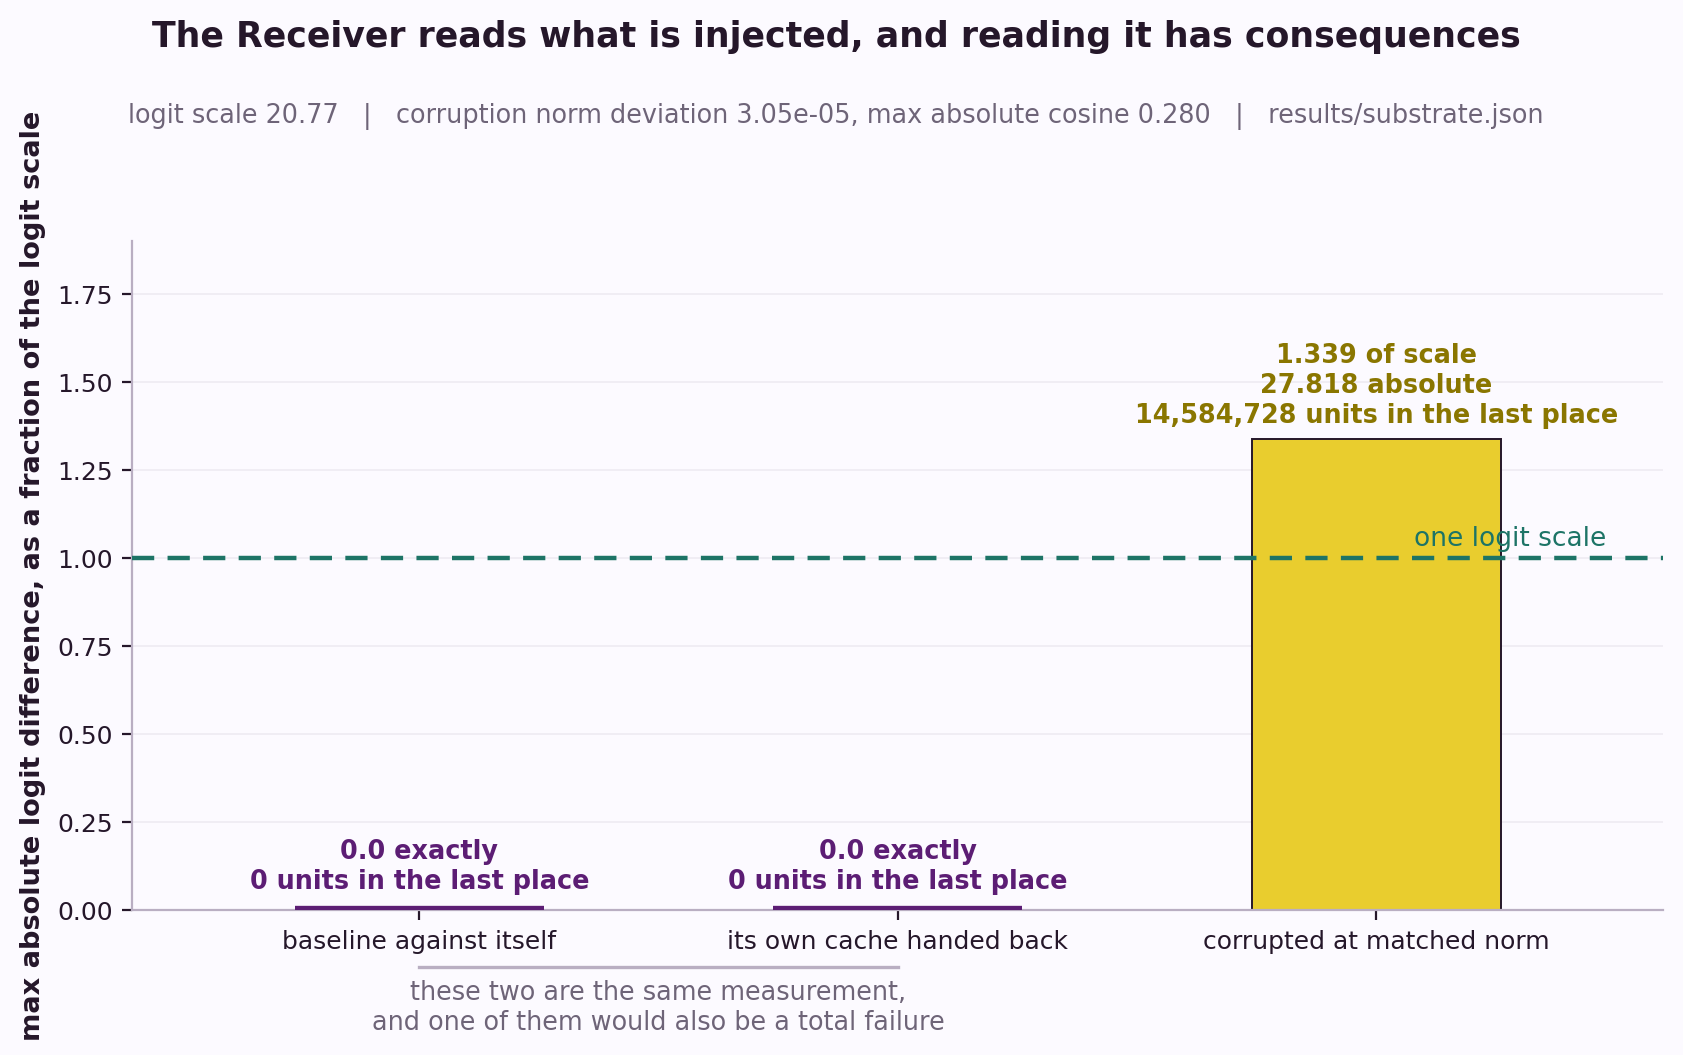

In [6]:
"""Three conditions on one axis, because no two of them settle anything.

Reads results/substrate.json. The first two bars are exactly zero and are
supposed to be: a cache handed back unchanged produces bit-identical logits,
and so does a cache the framework quietly discarded and recomputed. Those two
outcomes are the same measurement. The third bar is what tells them apart,
and it is drawn on the same axis for that reason rather than for symmetry.

The corruption is norm-matched, and the check for that is printed into the
subtitle rather than assumed, since a corruption that also changed the norm
would clear the threshold for the wrong reason.

Self-contained: run the whole cell. Writes assets/c2c_substrate_triptych.png
and displays it inline.
"""

import json
import os

import matplotlib.pyplot as plt

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

SUBSTRATE_PATH = os.path.join(_THIS_DIR, "results", "substrate.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_substrate_triptych.png")

CONDITIONS = [
    ("baseline_vs_itself", "baseline against itself"),
    ("noop_injection", "its own cache handed back"),
    ("corrupted_injection", "corrupted at matched norm"),
]
DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"
GOLD_INK = "#8A7600"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(path: str = SUBSTRATE_PATH) -> dict:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/capture_substrate.py first")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def build_triptych(substrate: dict, output_path: str = OUTPUT_PATH) -> list:
    ratios = [substrate["ratios"][key] for key, _ in CONDITIONS]
    absolute = [substrate["conditions"][key] for key, _ in CONDITIONS]
    ulps = [substrate["ulps"][key] for key, _ in CONDITIONS]
    labels = [label for _, label in CONDITIONS]
    scale = substrate["logit_scale"]

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.76, bottom=0.14, left=0.10, right=0.97)
    ax.set_facecolor(BG_COLOR)

    x = range(len(labels))
    colours = [PRIMARY, PRIMARY, SECONDARY]

    ax.axhline(1.0, color=TERTIARY, linewidth=1.6, linestyle=(0, (5, 3)), zorder=3)
    ax.text(len(labels) - 0.52, 1.02, "one logit scale", ha="right", va="bottom",
            fontsize=9.5, color=TERTIARY)

    ax.bar(x, ratios, width=0.52,
           color=[_mix(c, BG_COLOR, 0.18) for c in colours],
           edgecolor=TEXT_COLOR, linewidth=0.7, zorder=2)

    for i, (ratio, raw, ulp) in enumerate(zip(ratios, absolute, ulps)):
        if ratio == 0.0:
            ax.plot([i - 0.26, i + 0.26], [0, 0], color=PRIMARY, linewidth=3.0,
                    zorder=4, solid_capstyle="butt")
            ax.text(i, 0.045, "0.0 exactly\n0 units in the last place", ha="center",
                    va="bottom", fontsize=9.2, color=PRIMARY, fontweight="bold")
        else:
            ax.text(i, ratio + 0.03, f"{ratio:.3f} of scale\n{raw:.3f} absolute\n"
                                     f"{ulp:,.0f} units in the last place",
                    ha="center", va="bottom", fontsize=9.2, color=GOLD_INK,
                    fontweight="bold")

    bracket_y = -0.16
    ax.plot([0, 1], [bracket_y, bracket_y], color=MUTED, linewidth=1.2,
            clip_on=False, zorder=5)
    ax.text(0.5, bracket_y - 0.035,
            "these two are the same measurement,\nand one of them would also be a total failure",
            ha="center", va="top", fontsize=9.2, color="#6E6478", clip_on=False)

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, color=TEXT_COLOR, fontsize=10)
    ax.set_ylabel("max absolute logit difference, as a fraction of the logit scale",
                  fontsize=9.8, fontweight="bold", color=TEXT_COLOR)
    ax.set_ylim(0, max(ratios) * 1.42)
    ax.set_xlim(-0.6, len(labels) - 0.4)
    ax.grid(True, axis="y", color=MUTED, alpha=0.20, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED)

    check = substrate["corruption_check"]
    fig.suptitle("The Receiver reads what is injected, and reading it has consequences",
                 color=TEXT_COLOR, fontweight="bold", fontsize=12.5, y=0.965)
    fig.text(0.5, 0.888,
             f"logit scale {scale:.2f}   |   corruption norm deviation "
             f"{check['max_norm_deviation']:.2e}, max absolute cosine "
             f"{check['max_abs_cosine']:.3f}   |   results/substrate.json",
             ha="center", va="top", fontsize=9.2, color="#6E6478")

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR, bbox_inches="tight")
    plt.close(fig)
    return list(zip(labels, absolute, ratios))


def main() -> None:
    substrate = load()
    rows = build_triptych(substrate)
    for label, raw, ratio in rows:
        print(f"{label}: {raw:.6g} absolute, {ratio:.6g} of scale")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

aggregate over paired layers: keys 3.3431, values 13.2489
-> /home/claude/repo/assets/c2c_geometric_null.png


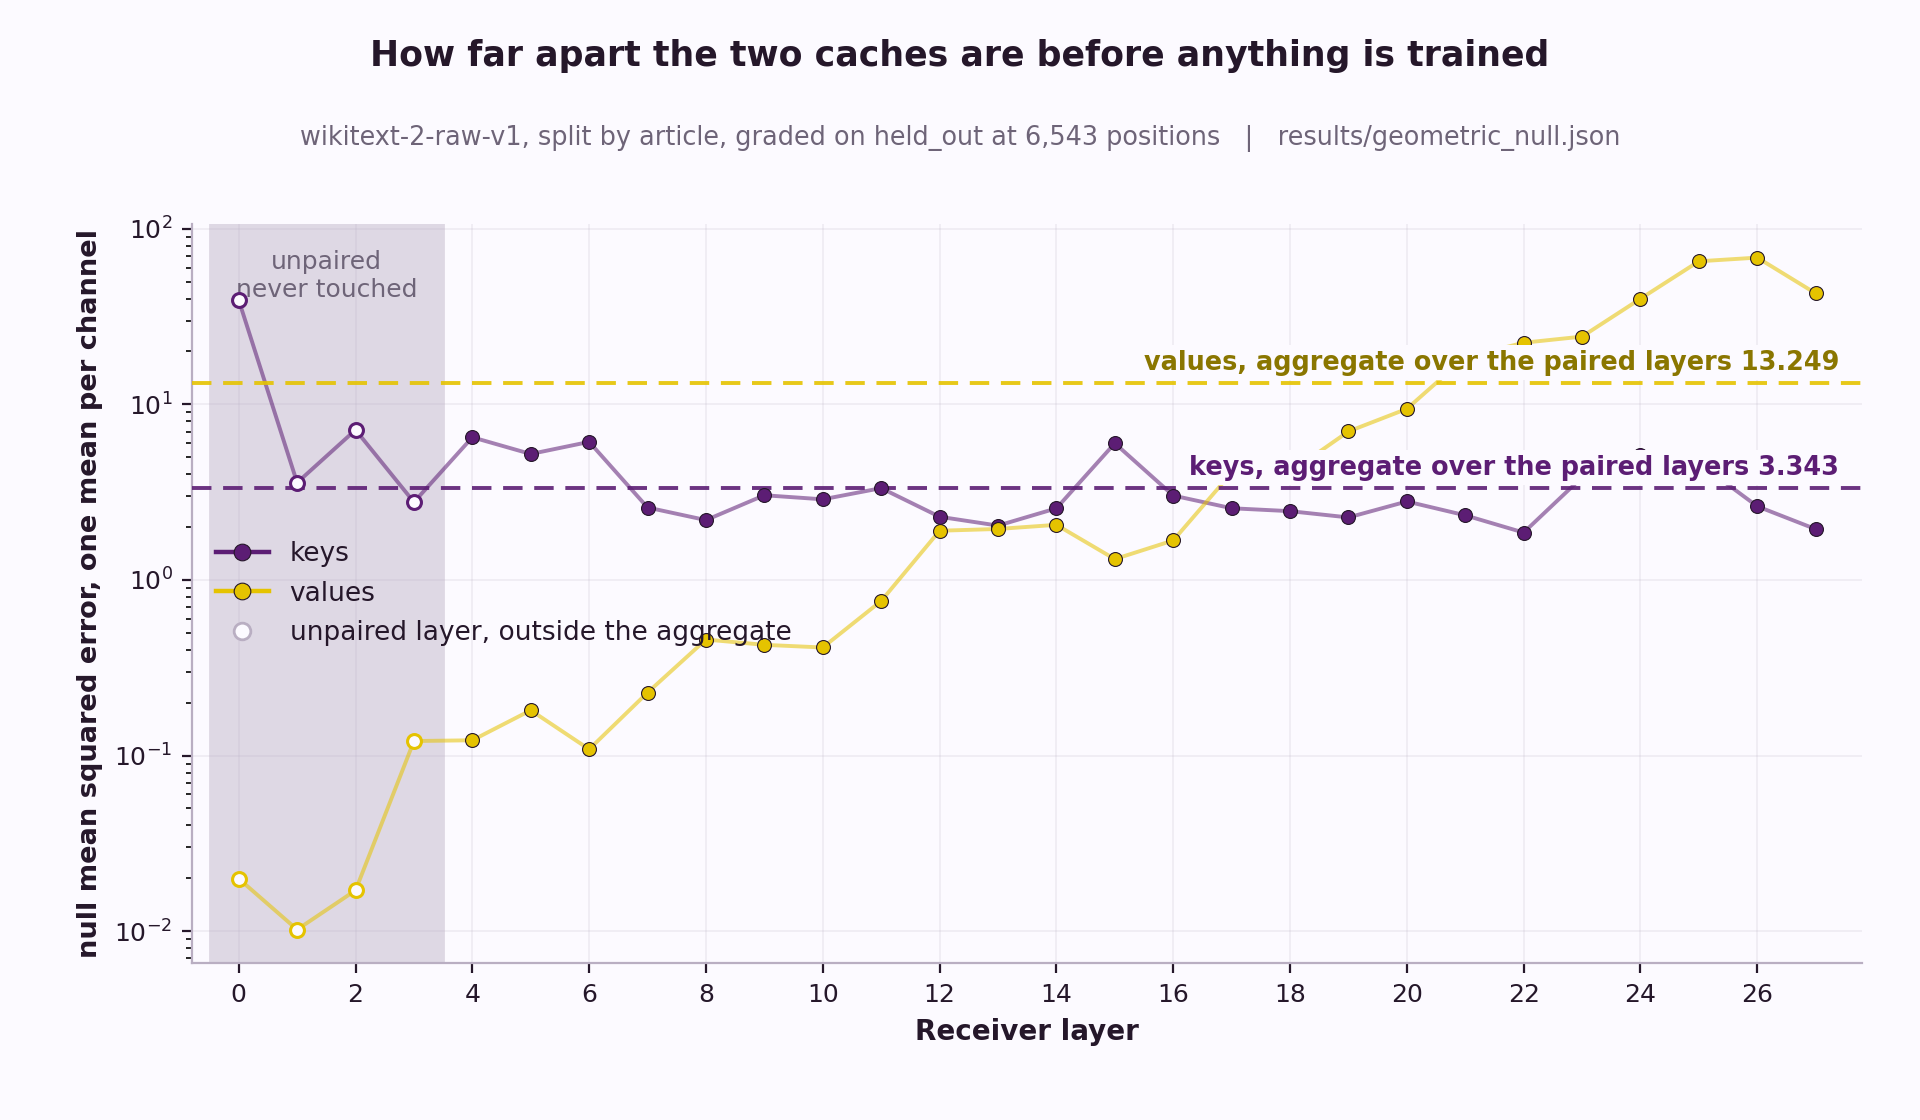

In [7]:
"""The floor every training loss below is a fraction of.

Reads results/geometric_null.json. Each point is the mean squared error of
the best constant predictor for one Receiver layer on the held-out split, one
mean per channel. A trained projection that ends above its own point here has
learned nothing, however far its curve fell.

The four unpaired layers are shaded rather than dropped. They are not part of
the aggregate the training figure divides by, and the shading is what stops
the first key layer from being read as a training result.

Self-contained: run the whole cell. Writes assets/c2c_geometric_null.png and
displays it inline.
"""

import json
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

NULL_PATH = os.path.join(_THIS_DIR, "results", "geometric_null.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_geometric_null.png")

GRADED_SPLIT = "held_out"
DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"
GOLD_INK = "#8A7600"

KEYS_COLOR = PRIMARY
VALUES_COLOR = SECONDARY


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(path: str = NULL_PATH) -> dict:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/capture_dual_cache.py first")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def build_geometric_null(null_file: dict, output_path: str = OUTPUT_PATH) -> dict:
    receiver = null_file["splits"][GRADED_SPLIT]["receiver"]
    paired = set(null_file["null"]["paired_target_layers"])
    unpaired = sorted(null_file["null"]["unpaired_target_layers"])
    aggregate = null_file["null"]["aggregate_paired_target_layers"]

    series = {
        kind: [record["null_mse_per_channel_mean"] for record in receiver[kind]]
        for kind in ("keys", "values")
    }
    n_layers = len(series["keys"])

    fig, ax = plt.subplots(figsize=(9.6, 5.6), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.80, bottom=0.14, left=0.10, right=0.97)
    ax.set_facecolor(BG_COLOR)

    if unpaired:
        ax.axvspan(min(unpaired) - 0.5, max(unpaired) + 0.5,
                   color=_mix(MUTED, BG_COLOR, 0.55), zorder=0)
        ax.text((min(unpaired) + max(unpaired)) / 2, 0.965,
                "unpaired\nnever touched", transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=9, color="#6E6478")

    for kind, colour in (("keys", KEYS_COLOR), ("values", VALUES_COLOR)):
        x_paired = [i for i in range(n_layers) if i in paired]
        y_paired = [series[kind][i] for i in x_paired]
        x_out = [i for i in range(n_layers) if i not in paired]
        y_out = [series[kind][i] for i in x_out]

        ax.plot(range(n_layers), series[kind], color=colour, linewidth=1.4,
                alpha=0.55, zorder=2)
        ax.plot(x_paired, y_paired, linestyle="none", marker="o", markersize=5.0,
                markerfacecolor=colour, markeredgecolor=TEXT_COLOR,
                markeredgewidth=0.4, zorder=4)
        ax.plot(x_out, y_out, linestyle="none", marker="o", markersize=5.0,
                markerfacecolor=BG_COLOR, markeredgecolor=colour,
                markeredgewidth=1.1, zorder=4)

        ax.axhline(aggregate[kind], color=colour, linewidth=1.4,
                   linestyle=(0, (5, 3)), alpha=0.9, zorder=3)
        ax.text(n_layers - 0.6, aggregate[kind] * 1.10,
                f"{kind}, aggregate over the paired layers {aggregate[kind]:.3f}",
                ha="right", va="bottom", fontsize=9.2,
                color=GOLD_INK if kind == "values" else colour, fontweight="bold",
                bbox=dict(facecolor=BG_COLOR, edgecolor="none", pad=1.6), zorder=6)

    ax.set_yscale("log")
    ax.set_xlabel("Receiver layer", fontsize=10, fontweight="bold", color=TEXT_COLOR)
    ax.set_ylabel("null mean squared error, one mean per channel", fontsize=9.8,
                  fontweight="bold", color=TEXT_COLOR)
    ax.set_xlim(-0.8, n_layers - 0.2)
    ax.set_xticks(range(0, n_layers, 2))
    ax.grid(True, color=MUTED, alpha=0.20, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED)

    legend = ax.legend(
        handles=[
            Line2D([], [], color=KEYS_COLOR, marker="o", linewidth=1.6,
                   markeredgecolor=TEXT_COLOR, markeredgewidth=0.4, label="keys"),
            Line2D([], [], color=VALUES_COLOR, marker="o", linewidth=1.6,
                   markeredgecolor=TEXT_COLOR, markeredgewidth=0.4, label="values"),
            Line2D([], [], color=MUTED, marker="o", linestyle="none",
                   markerfacecolor=BG_COLOR, markeredgecolor=MUTED,
                   label="unpaired layer, outside the aggregate"),
        ],
        loc="center left", frameon=False, fontsize=9.5,
    )
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)

    corpus = null_file["corpus"]
    n_positions = null_file["splits"][GRADED_SPLIT]["n_positions"]
    fig.suptitle("How far apart the two caches are before anything is trained",
                 color=TEXT_COLOR, fontweight="bold", fontsize=12.5, y=0.965)
    fig.text(0.5, 0.888,
             f"{corpus['config']}, split by {corpus['split_by']}, graded on "
             f"{GRADED_SPLIT} at {n_positions:,} positions   |   "
             "results/geometric_null.json",
             ha="center", va="top", fontsize=9.2, color="#6E6478")

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return aggregate


def main() -> None:
    null_file = load()
    aggregate = build_geometric_null(null_file)
    print(f"aggregate over paired layers: keys {aggregate['keys']:.4f}, "
          f"values {aggregate['values']:.4f}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

keys: mean 0.4761, worst 0.6667, layers above the null []
values: mean 0.6963, worst 0.8800, layers above the null []
highest point on any curve: 1.0818
-> /home/claude/repo/assets/c2c_loss_vs_null.png


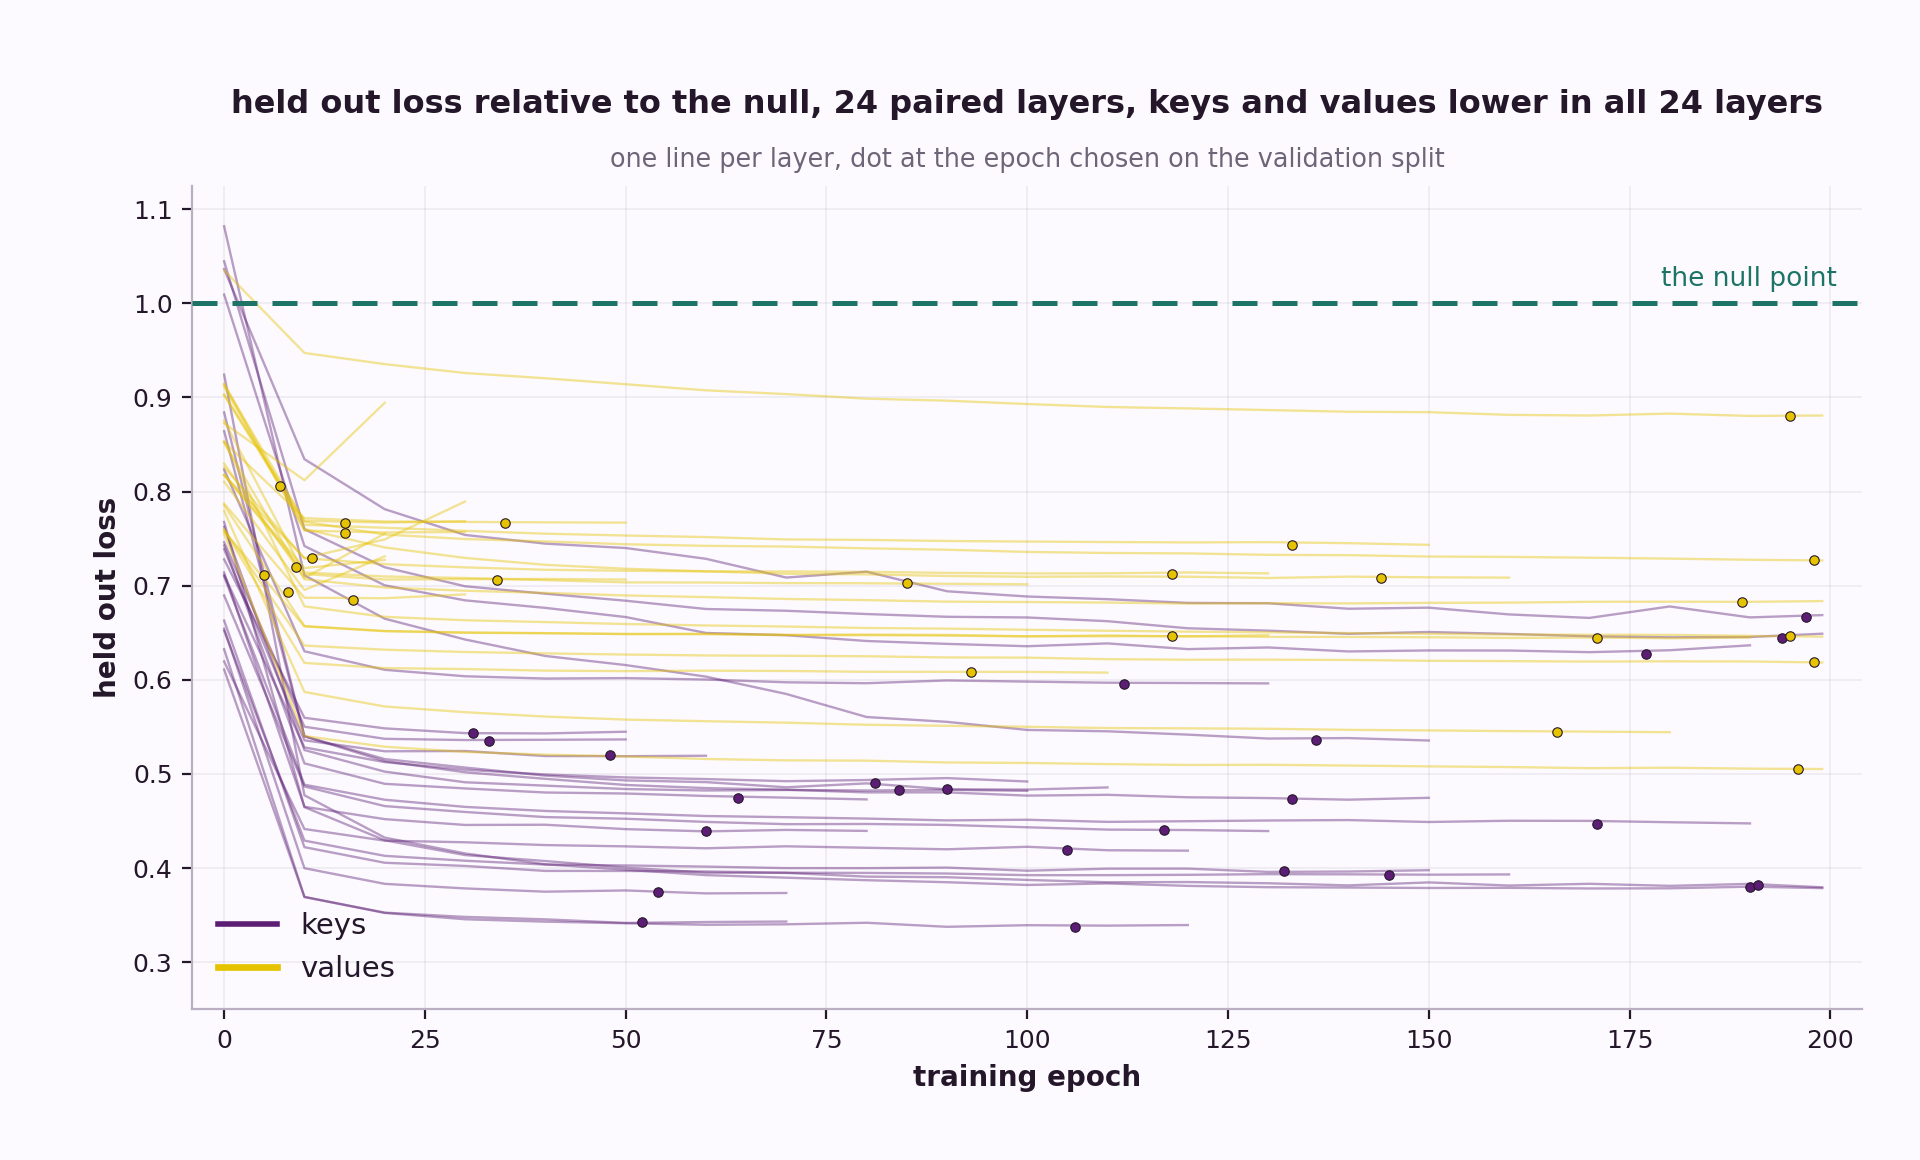

In [8]:
"""Every trained projection against the floor it had to clear.

Reads results/train_log.json, and reuses the null from the figure above as
the same object rather than a redrawn one: the y axis is held-out loss
divided by that null, so the pass criterion is a position on the page. That
division is also what makes keys and values comparable, since their targets
differ in scale by orders of magnitude across depth and a raw loss axis would
show that difference and nothing else.

Whether this figure should move was left to be decided after the run. It
should not. Five curves do cross the line, all of them at epoch zero and all
of them downward: an untrained projection sits at the null, which is what the
null means. No curve ends above it and none returns to it, so an animation
would show every line falling in its first frame and then holding, which is a
sequence with one event in it and that event is the initialisation.

Self-contained: run the whole cell. Writes assets/c2c_loss_vs_null.png and
displays it inline.
"""

import json
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

LOG_PATH = os.path.join(_THIS_DIR, "results", "train_log.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_loss_vs_null.png")

DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"

# A two way categorical is violet against gold. Teal is the reference line,
# which is a role of a different kind rather than a third series.
KEYS_COLOR = PRIMARY
VALUES_COLOR = SECONDARY
NULL_COLOR = TERTIARY


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(path: str = LOG_PATH) -> dict:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/train_projection.py first")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def build_loss_vs_null(log: dict, output_path: str = OUTPUT_PATH) -> float:
    fig, ax = plt.subplots(figsize=(9.6, 5.8), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.84, bottom=0.13, left=0.10, right=0.97)
    ax.set_facecolor(BG_COLOR)

    ax.axhline(1.0, color=NULL_COLOR, linewidth=1.8, linestyle=(0, (5, 3)), zorder=4)
    ax.annotate(
        "the null point",
        xy=(0.985, 1.012), xycoords=("axes fraction", "data"),
        ha="right", va="bottom", fontsize=9.5, color=NULL_COLOR, zorder=6,
    )

    highest = 0.0
    for record in log["per_layer"]:
        kind = record["kind"]
        colour = KEYS_COLOR if kind == "keys" else VALUES_COLOR
        null = record["null_held_out"]
        epochs = [p["epoch"] for p in record["curve"]]
        losses = [p["held_out"] / null for p in record["curve"]]
        highest = max(highest, max(losses))
        ax.plot(epochs, losses, color=colour, linewidth=0.85, alpha=0.42,
                zorder=2 if kind == "keys" else 3)
        ax.plot([record["selected_epoch"]], [record["relative_held_out"]],
                marker="o", markersize=3.4, color=colour,
                markeredgecolor=TEXT_COLOR, markeredgewidth=0.4, zorder=5)

    ax.set_xlabel("training epoch", fontsize=10, fontweight="bold", color=TEXT_COLOR)
    ax.set_ylabel("held out loss", fontsize=10, fontweight="bold", color=TEXT_COLOR)
    ax.set_ylim(0.25, max(1.12, highest * 1.04))
    ax.set_xlim(-4, 204)
    ax.grid(True, color=MUTED, alpha=0.22, linewidth=0.6)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED)

    n = log["summary"]["keys"]["n_layers"]
    ax.set_title(
        f"held out loss relative to the null, {n} paired layers, keys and values "
        f"lower in all {n} layers",
        fontsize=11.5, color=TEXT_COLOR, pad=26, fontweight="bold",
    )
    ax.annotate(
        "one line per layer, dot at the epoch chosen on the validation split",
        xy=(0.5, 1.015), xycoords="axes fraction", ha="center", va="bottom",
        fontsize=9.2, color="#6E6478",
    )

    legend = ax.legend(
        handles=[
            Line2D([], [], color=KEYS_COLOR, linewidth=2.0, label="keys"),
            Line2D([], [], color=VALUES_COLOR, linewidth=2.4, label="values"),
        ],
        loc="lower left", frameon=False, fontsize=10.5,
    )
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return highest


def main() -> None:
    log = load()
    highest = build_loss_vs_null(log)
    summary = log["summary"]
    for kind in ("keys", "values"):
        s = summary[kind]
        print(f"{kind}: mean {s['mean_relative_held_out']:.4f}, "
              f"worst {s['worst_relative_held_out']:.4f}, "
              f"layers above the null {s['layers_above_null']}")
    print(f"highest point on any curve: {highest:.4f}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

read run_2026-08-07_n500.json
fused minus replace: +0.208 [+0.148, +0.268] p = 7.99e-11
fused minus baseline: +0.076 [+0.038, +0.112] p = 7.66e-05
replace minus baseline: -0.132 [-0.196, -0.068] p = 5.09e-05
projection_mse minus baseline: -0.184 [-0.230, -0.138] p = 3.60e-14
-> /home/claude/repo/assets/c2c_accuracy_interval.png


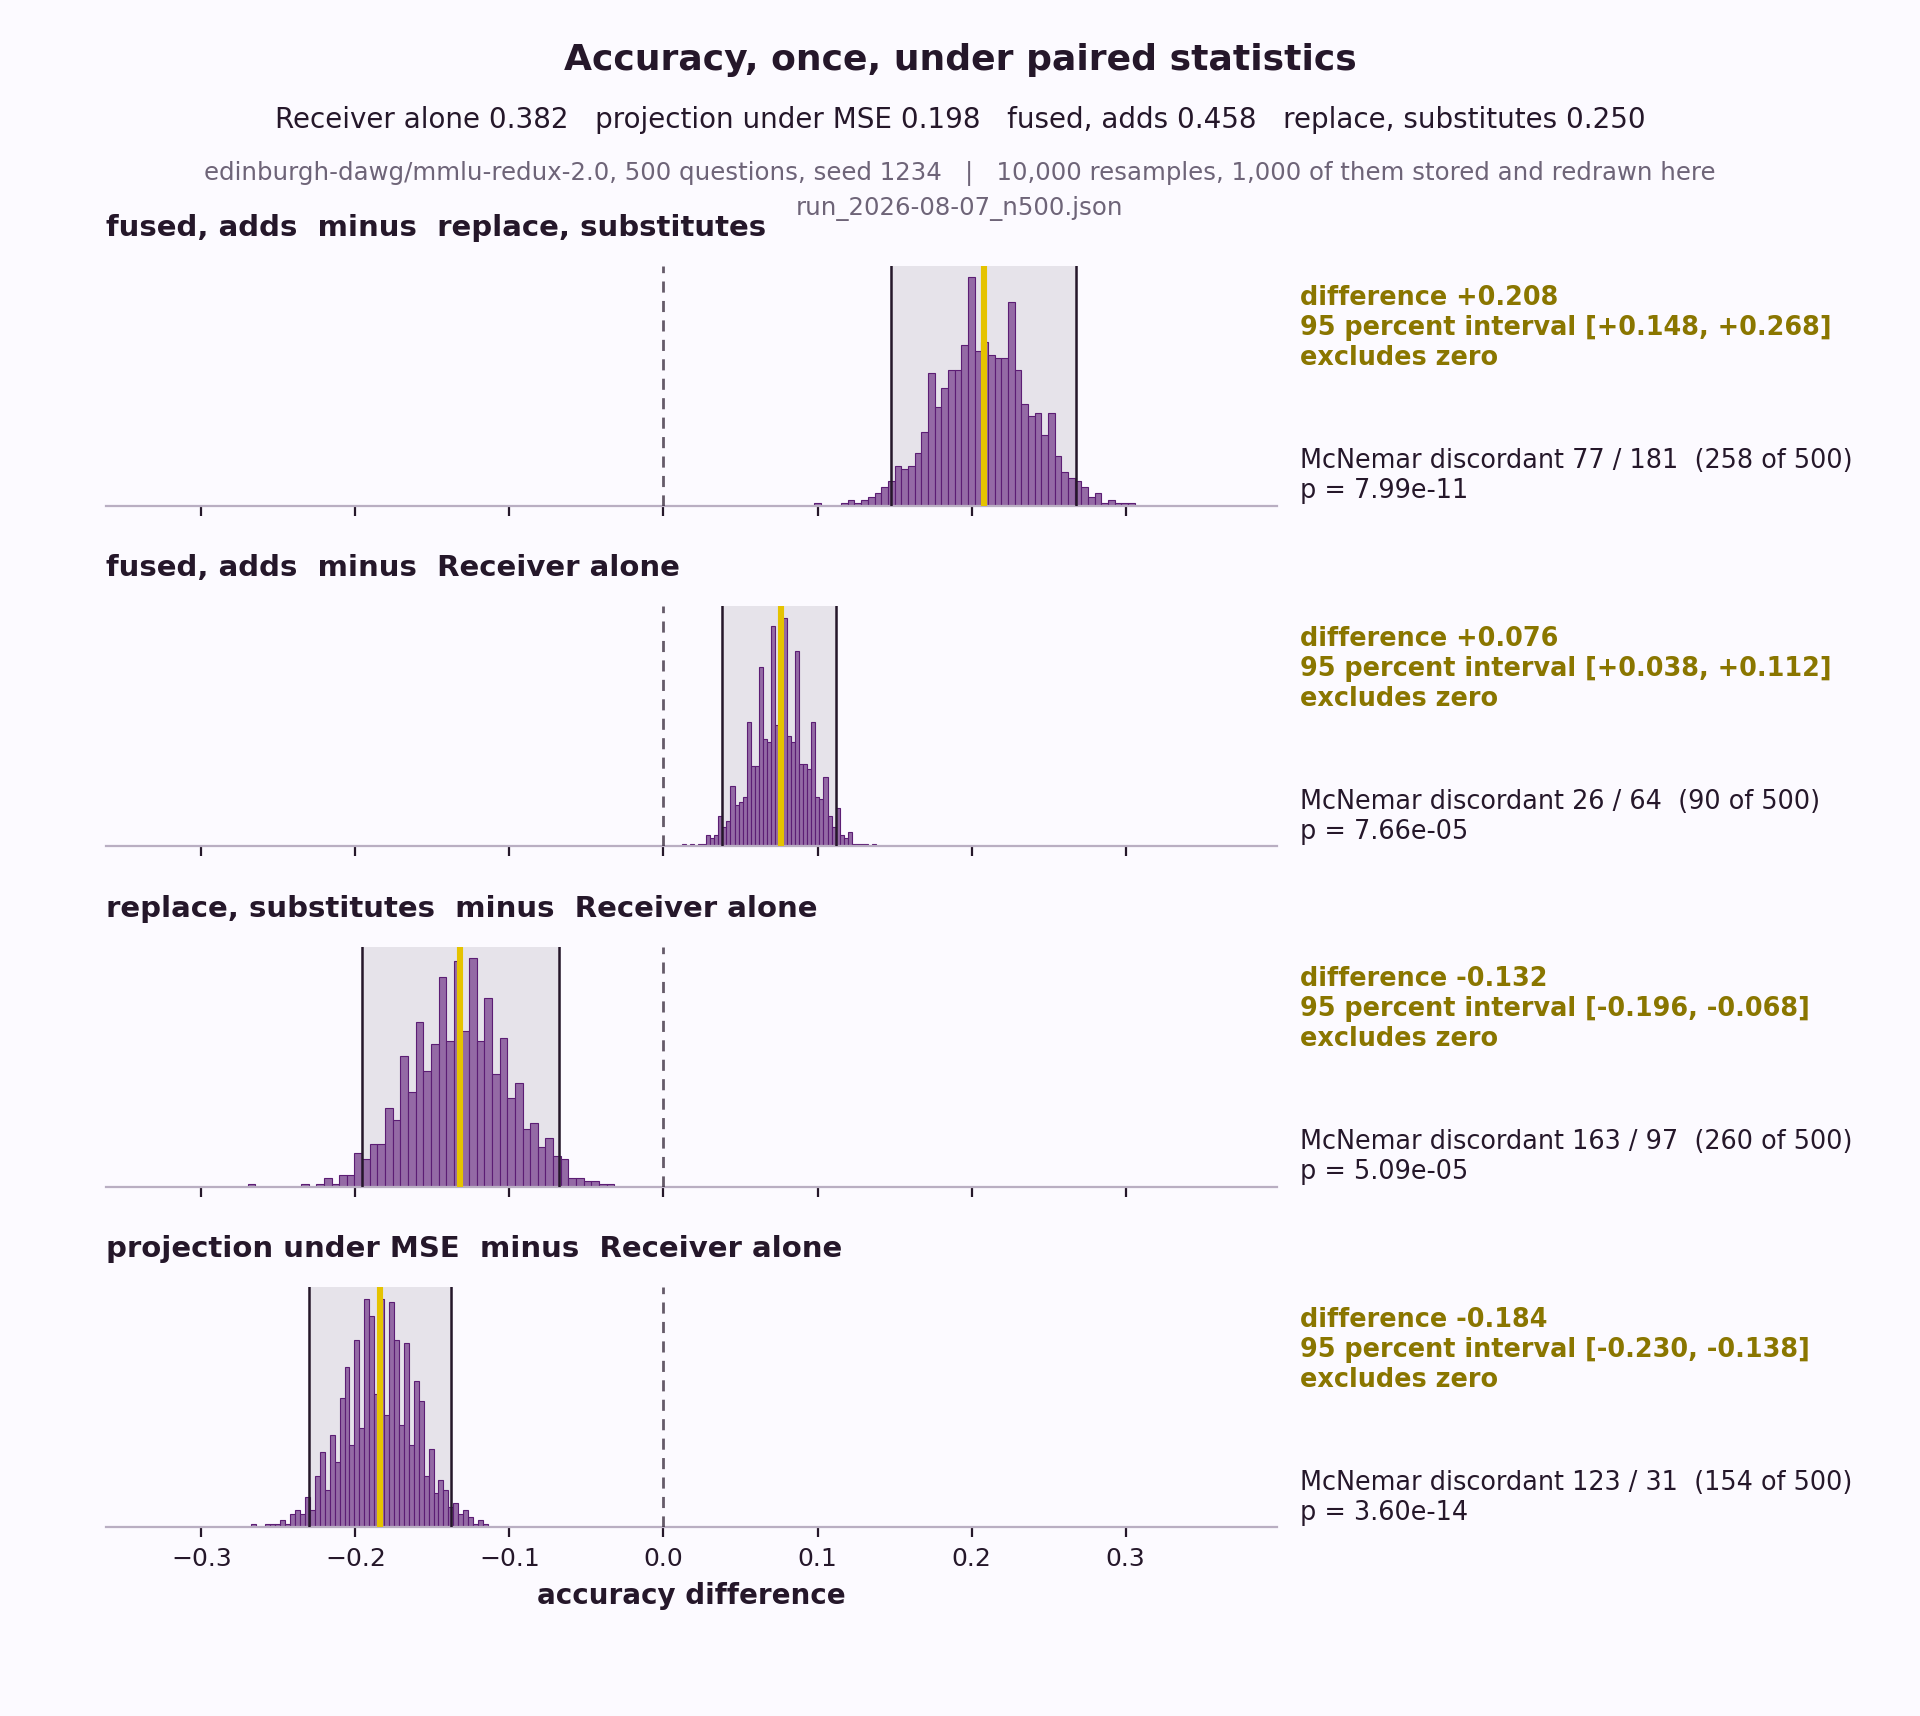

In [9]:
"""Every paired comparison the graded run recorded, on one shared axis.

Reads results/run_<date>_n<N>.json, the most recent one in results/. Each
panel is the recorded bootstrap distribution of an accuracy difference, with
the interval marked and the McNemar discordant counts printed beside it. The
construction is the one used in the neighbouring repository, deliberately, so
that a reader moving between the two does not have to relearn the reading.

The x axis is shared across panels. That is the whole reason the panels are
stacked rather than drawn separately: an interval that excludes zero and an
interval that excludes it by four times as much are different claims, and a
per-panel axis would hide the difference.

An interval says how repeatable a difference is. It says nothing about
whether the number it is an interval on is an accuracy or a base rate, which
is what the answer distribution figure is for.

Self-contained: run the whole cell. Writes assets/c2c_accuracy_interval.png
and displays it inline.
"""

import glob
import json
import os

import numpy as np
import matplotlib.pyplot as plt

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

RESULTS_DIR = os.path.join(_THIS_DIR, "results")
RUN_GLOB = os.path.join(RESULTS_DIR, "run_*_n*.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_accuracy_interval.png")

LABELS = {
    "baseline": "Receiver alone",
    "fused": "fused, adds",
    "replace": "replace, substitutes",
    "projection_mse": "projection under MSE",
    "injected": "projection under MSE",
}
DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"
GOLD_INK = "#8A7600"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(pattern: str = RUN_GLOB) -> tuple[dict, str]:
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise SystemExit(f"no file matching {pattern}; run scripts/analysis.py first")
    path = paths[-1]
    with open(path, encoding="utf-8") as f:
        return json.load(f), path


def _comparisons(run: dict) -> list[dict]:
    if "comparisons" in run:
        rows = list(run["comparisons"].values())
    else:
        conditions = run["conditions"]
        rows = [{
            "a": conditions[0], "b": conditions[1],
            "bootstrap": run["bootstrap"],
            "mcnemar": {
                "a_only": run["mcnemar"]["b_baseline_only"],
                "b_only": run["mcnemar"]["c_injected_only"],
                "n_discordant": run["mcnemar"]["n_discordant"],
                "p_value": run["mcnemar"]["p_value"],
            },
        }]
    return sorted(rows, key=lambda r: -r["bootstrap"]["difference"])


def build_accuracy_interval(run: dict, run_path: str,
                            output_path: str = OUTPUT_PATH) -> list[dict]:
    rows = _comparisons(run)
    accuracy = run["accuracy"]

    spread = [v for row in rows for v in row["bootstrap"]["distribution"]]
    low, high = min(spread), max(spread)
    pad = 0.16 * (high - low)

    fig, axes = plt.subplots(len(rows), 1, figsize=(9.6, 1.62 * len(rows) + 2.1),
                             sharex=True, facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.845, bottom=0.11, left=0.055, right=0.665, hspace=0.42)
    axes = np.atleast_1d(axes)

    for ax, row in zip(axes, rows):
        boot, mcnemar = row["bootstrap"], row["mcnemar"]
        draws = np.asarray(boot["distribution"], dtype=float)

        ax.set_facecolor(BG_COLOR)
        ax.axvspan(boot["low"], boot["high"],
                   color=_mix(TEXT_COLOR, BG_COLOR, 0.90), zorder=0)
        ax.hist(draws, bins=48, color=_mix(PRIMARY, BG_COLOR, 0.35),
                edgecolor=PRIMARY, linewidth=0.4, zorder=2)
        ax.axvline(0, color=TEXT_COLOR, linewidth=1.0, linestyle=(0, (4, 3)),
                   alpha=0.7, zorder=3)
        ax.axvline(boot["difference"], color=SECONDARY, linewidth=2.2, zorder=4)
        for edge in (boot["low"], boot["high"]):
            ax.axvline(edge, color=TEXT_COLOR, linewidth=0.9, zorder=3)

        ax.set_yticks([])
        ax.set_xlim(low - pad, high + pad)
        ax.tick_params(colors=TEXT_COLOR, labelsize=9)
        for spine in ("top", "right", "left"):
            ax.spines[spine].set_visible(False)
        ax.spines["bottom"].set_color(MUTED)

        a_label = LABELS.get(row["a"], row["a"])
        b_label = LABELS.get(row["b"], row["b"])
        ax.text(0.0, 1.10, f"{b_label}  minus  {a_label}", transform=ax.transAxes,
                ha="left", va="bottom", fontsize=10.5, fontweight="bold",
                color=TEXT_COLOR)

        excludes_zero = boot["low"] > 0 or boot["high"] < 0
        ax.text(1.02, 0.92,
                f"difference {boot['difference']:+.3f}\n"
                f"{int(boot['interval'] * 100)} percent interval "
                f"[{boot['low']:+.3f}, {boot['high']:+.3f}]\n"
                f"{'excludes zero' if excludes_zero else 'crosses zero'}",
                transform=ax.transAxes, ha="left", va="top", fontsize=9.2,
                color=GOLD_INK if excludes_zero else "#6E6478", fontweight="bold")
        ax.text(1.02, 0.24,
                f"McNemar discordant {mcnemar['a_only']} / {mcnemar['b_only']}"
                f"  ({mcnemar['n_discordant']} of {run['corpus']['n_sampled']})\n"
                f"p = {mcnemar['p_value']:.2e}",
                transform=ax.transAxes, ha="left", va="top", fontsize=9.2,
                color=TEXT_COLOR)

    axes[-1].set_xlabel("accuracy difference", fontsize=10, fontweight="bold",
                        color=TEXT_COLOR)

    scores = "   ".join(
        f"{LABELS.get(name, name)} {value:.3f}" for name, value in accuracy.items()
    )
    n_resamples = rows[0]["bootstrap"]["n_resamples"]
    stored = len(rows[0]["bootstrap"]["distribution"])

    fig.suptitle("Accuracy, once, under paired statistics",
                 color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.975)
    fig.text(0.5, 0.938, scores, ha="center", va="top", fontsize=10,
             color=TEXT_COLOR)
    fig.text(0.5, 0.906,
             f"{run['corpus']['dataset']}, {run['corpus']['n_sampled']} questions, "
             f"seed {run['corpus']['sample_seed']}   |   {n_resamples:,} resamples, "
             f"{stored:,} of them stored and redrawn here\n"
             f"{os.path.basename(run_path)}",
             ha="center", va="top", fontsize=8.8, color="#6E6478",
             linespacing=1.5)

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return rows


def main() -> None:
    run, run_path = load()
    rows = build_accuracy_interval(run, run_path)
    print(f"read {os.path.basename(run_path)}")
    for row in rows:
        boot = row["bootstrap"]
        print(f"{row['b']} minus {row['a']}: {boot['difference']:+.3f} "
              f"[{boot['low']:+.3f}, {boot['high']:+.3f}] "
              f"p = {row['mcnemar']['p_value']:.2e}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

key:      A 98  B 125  C 121  D 156
baseline: A 266  B 52  C 70  D 112   total variation from the key 0.336
projection_mse: A 498  B 0  C 2  D 0   total variation from the key 0.800
fused: A 157  B 93  C 113  D 137   total variation from the key 0.118
replace: A 0  B 497  C 3  D 0   total variation from the key 0.744
-> /home/claude/repo/assets/c2c_answer_distributions.png


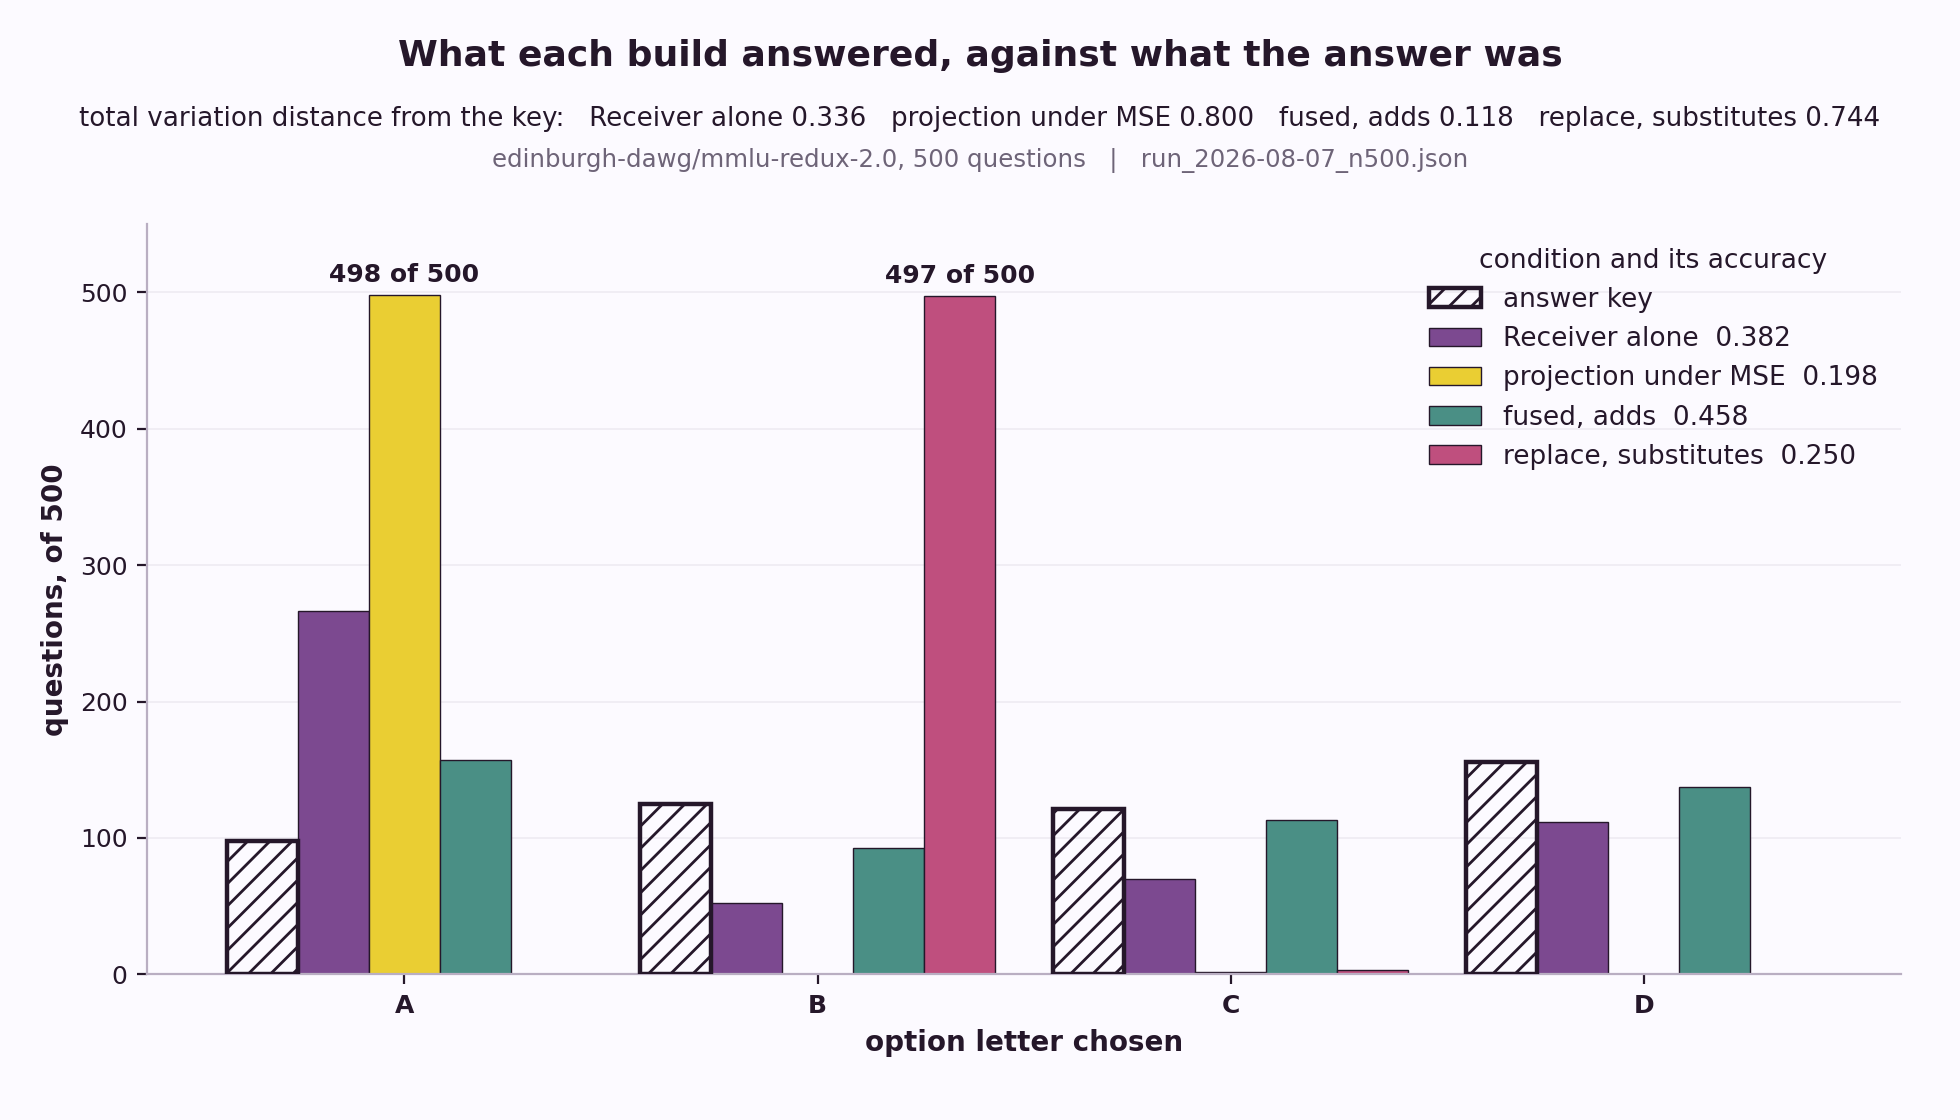

In [10]:
"""Every condition's answer distribution, against the key drawn as a series.

Reads results/run_<date>_n<N>.json, the most recent one in results/.

This is the figure this project would most regret not having. An accuracy
near the base rate of a single letter and an accuracy earned across four are
the same number, and nothing in an interval or a paired test tells them
apart. Twice a build here has scored what looked like a low accuracy and had
in fact stopped reading the question, once onto A and once onto B, and both
times this distribution is what made it visible in one glance.

The key is drawn in the same axes rather than annotated. A collapse is a
claim about the distance between two distributions, and that distance has to
be something the eye measures rather than something the caption asserts. The
total variation distance printed beside each condition is the same claim as a
number, computed here rather than read from the file.

Self-contained: run the whole cell. Writes
assets/c2c_answer_distributions.png and displays it inline.
"""

import glob
import json
import os
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

RESULTS_DIR = os.path.join(_THIS_DIR, "results")
RUN_GLOB = os.path.join(RESULTS_DIR, "run_*_n*.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_answer_distributions.png")

LABELS = {
    "baseline": "Receiver alone",
    "fused": "fused, adds",
    "replace": "replace, substitutes",
    "projection_mse": "projection under MSE",
    "injected": "projection under MSE",
}
DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
QUATERNARY = "#B0245E"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"

CONDITION_COLOURS = [PRIMARY, SECONDARY, TERTIARY, QUATERNARY]


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(pattern: str = RUN_GLOB) -> tuple[dict, str]:
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise SystemExit(f"no file matching {pattern}; run scripts/analysis.py first")
    path = paths[-1]
    with open(path, encoding="utf-8") as f:
        return json.load(f), path


def _answer_key(run: dict, n_options: int) -> list[int]:
    counts = Counter(record["answer"] for record in run["per_sample"])
    return [counts.get(i, 0) for i in range(n_options)]


def _distributions(run: dict, n_options: int) -> dict[str, list[int]]:
    if "answer_distribution" in run:
        return {name: list(counts)
                for name, counts in run["answer_distribution"].items()}
    out = {}
    for condition in run["conditions"]:
        counts = Counter(record[f"{condition}_choice"] for record in run["per_sample"])
        out[condition] = [counts.get(i, 0) for i in range(n_options)]
    return out


def _total_variation(a: list[int], b: list[int]) -> float:
    pa = np.asarray(a, dtype=float) / max(sum(a), 1)
    pb = np.asarray(b, dtype=float) / max(sum(b), 1)
    return float(0.5 * np.abs(pa - pb).sum())


def build_answer_distributions(run: dict, run_path: str,
                               output_path: str = OUTPUT_PATH) -> list[tuple]:
    letters = run["option_letters"]
    n_options = len(letters)
    key = _answer_key(run, n_options)
    distributions = _distributions(run, n_options)
    accuracy = run["accuracy"]
    n = sum(key)

    names = list(distributions.keys())
    rows = [(name, distributions[name], _total_variation(distributions[name], key))
            for name in names]

    fig, ax = plt.subplots(figsize=(9.8, 5.6), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.80, bottom=0.13, left=0.075, right=0.97)
    ax.set_facecolor(BG_COLOR)

    n_series = len(rows) + 1
    width = 0.86 / n_series
    x = np.arange(n_options)

    ax.bar(x - 0.43 + width / 2, key, width=width, facecolor="none",
           edgecolor=TEXT_COLOR, linewidth=1.6, hatch="///", zorder=3,
           label="answer key")

    for i, (name, counts, _) in enumerate(rows, start=1):
        colour = CONDITION_COLOURS[(i - 1) % len(CONDITION_COLOURS)]
        ax.bar(x - 0.43 + width * (i + 0.5), counts, width=width,
               facecolor=_mix(colour, BG_COLOR, 0.20), edgecolor=TEXT_COLOR,
               linewidth=0.5, zorder=2,
               label=f"{LABELS.get(name, name)}  {accuracy[name]:.3f}")

    for i, (name, counts, _) in enumerate(rows, start=1):
        top = max(counts)
        if top / n > 0.75:
            ax.text(x[int(np.argmax(counts))] - 0.43 + width * (i + 0.5), top + n * 0.012,
                    f"{top} of {n}", ha="center", va="bottom", fontsize=9,
                    color=TEXT_COLOR, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(letters, fontsize=12, color=TEXT_COLOR, fontweight="bold")
    ax.set_xlabel("option letter chosen", fontsize=10, fontweight="bold",
                  color=TEXT_COLOR)
    ax.set_ylabel(f"questions, of {n}", fontsize=10, fontweight="bold",
                  color=TEXT_COLOR)
    ax.set_ylim(0, n * 1.10)
    ax.grid(True, axis="y", color=MUTED, alpha=0.20, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED)

    legend = ax.legend(loc="upper right", frameon=False, fontsize=9.5, ncol=1,
                       title="condition and its accuracy")
    legend.get_title().set_color(TEXT_COLOR)
    legend.get_title().set_fontsize(9.5)
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)

    distances = "   ".join(
        f"{LABELS.get(name, name)} {tv:.3f}" for name, _, tv in rows
    )
    fig.suptitle("What each build answered, against what the answer was",
                 color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.965)
    fig.text(0.5, 0.905,
             f"total variation distance from the key:   {distances}",
             ha="center", va="top", fontsize=9.4, color=TEXT_COLOR)
    fig.text(0.5, 0.868,
             f"{run['corpus']['dataset']}, {n} questions   |   "
             f"{os.path.basename(run_path)}",
             ha="center", va="top", fontsize=8.8, color="#6E6478")

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return rows, key


def main() -> None:
    run, run_path = load()
    rows, key = build_answer_distributions(run, run_path)
    letters = run["option_letters"]
    print("key:      " + "  ".join(f"{l} {c}" for l, c in zip(letters, key)))
    for name, counts, tv in rows:
        print(f"{name}: " + "  ".join(f"{l} {c}" for l, c in zip(letters, counts))
              + f"   total variation from the key {tv:.3f}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

read fuser_fused_2026-08-06_n2000.json, 33 frames
first step with any gate open: 160
final activation ratio 0.0417   open key gates at layers []   open value gates at layers [13, 25]
-> /home/claude/repo/assets/c2c_gate_anneal.gif


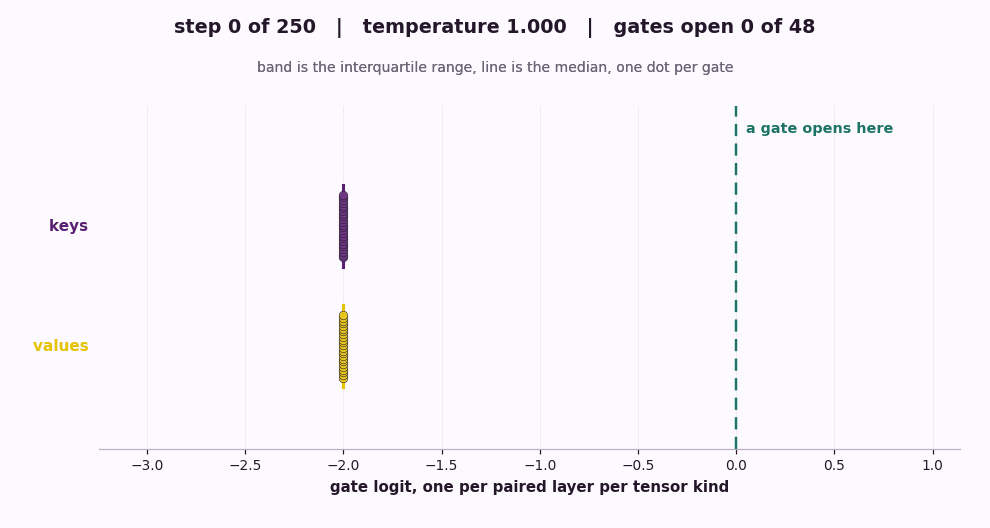

In [11]:
"""Animated: the gate logits hardening as the temperature falls.

Reads results/fuser_fused_<date>_n<N>.json, the most recent one in results/,
and results/contracts.json for the layer numbers. The second file is not
decoration: the gate arrays are indexed by pair, and the pairs start at
Receiver layer 4, so labelling a dot with its position in the array would put
every open gate four layers too shallow.

Each frame is the distribution of the 48 recorded gate logits, two per paired
layer, at one training step. The animation is earned rather than decorative:
the frames are distributions and the hardening between them is continuous, so
a row of small multiples would hide the property the figure exists to show.

Drawn from the recorded logits, not from the Gumbel-sigmoid formula. The
formula version would be a textbook illustration of a function and would say
nothing about which layers of this Receiver end up open, which is the part
that is a fact about this run.

Self-contained: run the whole cell. Writes assets/c2c_gate_anneal.gif and
displays it inline.
"""

import glob
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

RESULTS_DIR = os.path.join(_THIS_DIR, "results")
FUSER_GLOB = os.path.join(RESULTS_DIR, "fuser_fused_*_n*.json")
CONTRACTS_PATH = os.path.join(RESULTS_DIR, "contracts.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_gate_anneal.gif")

FRAME_STRIDE = 1
FPS = 8
N_BINS = 30
DPI = 110

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"
GOLD_INK = "#8A7600"

KEYS_COLOR = PRIMARY
VALUES_COLOR = SECONDARY


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(pattern: str = FUSER_GLOB) -> tuple[dict, str]:
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise SystemExit(f"no file matching {pattern}; run scripts/train_fuser.py first")
    path = paths[-1]
    with open(path, encoding="utf-8") as f:
        return json.load(f), path


def paired_target_layers(path: str = CONTRACTS_PATH) -> list[int]:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/capture_contracts.py first")
    with open(path, encoding="utf-8") as f:
        contract = json.load(f)
    return sorted(target for target, _ in contract["layer_alignment"]["pairs"])


def _frames(history: list[dict], stride: int) -> list[dict]:
    recorded = [entry for entry in history if "gate_logits" in entry]
    kept = recorded[::stride]
    if kept and recorded and kept[-1]["step"] != recorded[-1]["step"]:
        kept.append(recorded[-1])
    return kept


def build_gate_anneal(log: dict, source: str, layers: list[int],
                      output_path: str = OUTPUT_PATH) -> dict:
    frames = _frames(log["history"], FRAME_STRIDE)
    if not frames:
        raise SystemExit("no gate logits recorded in the history")
    n_gates = len(frames[0]["gate_logits"]["keys"])
    if len(layers) != n_gates:
        raise SystemExit(f"{len(layers)} paired layers against {n_gates} gates per kind")

    everything = np.array([v for entry in frames
                           for kind in ("keys", "values")
                           for v in entry["gate_logits"][kind]])
    lo, hi = float(everything.min()), float(everything.max())
    pad = 0.14 * (hi - lo)
    x_lo, x_hi = lo - pad, hi + pad

    first_crossing = next(
        (entry["step"] for entry in log["history"]
         if entry.get("gate_activation_ratio", 0.0) > 0.0), None
    )

    # Deterministic vertical offsets so that identical logits, which is exactly
    # what the first frame contains, stack instead of hiding one another.
    offsets = np.linspace(-0.26, 0.26, n_gates)

    fig, ax = plt.subplots(figsize=(9.0, 4.8), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.80, bottom=0.15, left=0.10, right=0.97)

    def draw(index: int):
        entry = frames[index]
        ax.clear()
        ax.set_facecolor(BG_COLOR)
        ax.axvline(0.0, color=TERTIARY, linewidth=1.6, linestyle=(0, (5, 3)),
                   zorder=5)
        ax.text(0.0, 1.86, "  a gate opens here", ha="left", va="top",
                fontsize=9.4, color=TERTIARY, fontweight="bold")

        n_open = 0
        for row, (kind, colour) in enumerate((("keys", KEYS_COLOR),
                                              ("values", VALUES_COLOR))):
            series = np.array(entry["gate_logits"][kind], dtype=float)
            y = 1.0 - row

            q1, median, q3 = np.percentile(series, [25, 50, 75])
            ax.add_patch(plt.Rectangle((q1, y - 0.34), q3 - q1, 0.68,
                                       facecolor=_mix(colour, BG_COLOR, 0.80),
                                       edgecolor="none", zorder=1))
            ax.plot([median, median], [y - 0.34, y + 0.34], color=colour,
                    linewidth=2.0, zorder=2)

            ax.plot(series, y + offsets, linestyle="none", marker="o",
                    markersize=5.6, markerfacecolor=_mix(colour, BG_COLOR, 0.12),
                    markeredgecolor=TEXT_COLOR, markeredgewidth=0.4, alpha=0.9,
                    zorder=3)

            open_gates = [(logit, pair_index)
                          for pair_index, logit in enumerate(series) if logit > 0.0]
            n_open += len(open_gates)
            for rank, (logit, pair_index) in enumerate(sorted(open_gates)):
                ax.annotate(
                    f"layer {layers[pair_index]}",
                    xy=(logit, y + offsets[pair_index]),
                    xytext=(logit, y + 0.46 + 0.24 * rank), ha="center",
                    va="bottom", fontsize=8.8, color=GOLD_INK, fontweight="bold",
                    arrowprops=dict(arrowstyle="-", color=GOLD_INK,
                                    linewidth=0.8), zorder=6,
                )
            ax.text(x_lo, y, kind + "  ", ha="right", va="center", fontsize=10,
                    color=colour, fontweight="bold")

        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(-0.85, 2.0)
        ax.set_yticks([])
        ax.set_xlabel("gate logit, one per paired layer per tensor kind",
                      fontsize=9.8, fontweight="bold", color=TEXT_COLOR)
        ax.grid(True, axis="x", color=MUTED, alpha=0.20, linewidth=0.6)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TEXT_COLOR, labelsize=9)
        for spine in ("top", "right", "left"):
            ax.spines[spine].set_visible(False)
        ax.spines["bottom"].set_color(MUTED)

        n_total = 2 * n_gates
        fig.suptitle(
            f"step {entry['step']} of {log['total_steps']}   |   "
            f"temperature {entry['temperature']:.3f}   |   "
            f"gates open {n_open} of {n_total}",
            color=TEXT_COLOR, fontweight="bold", fontsize=12.5, y=0.965,
        )
        fig.text(0.5, 0.885,
                 "band is the interquartile range, line is the median, "
                 "one dot per gate",
                 ha="center", va="top", fontsize=9.2, color="#6E6478")
        return []

    anim = animation.FuncAnimation(fig, draw, frames=len(frames), interval=1000 // FPS)
    anim.save(output_path, writer=animation.PillowWriter(fps=FPS), dpi=DPI,
              savefig_kwargs={"facecolor": BG_COLOR})
    plt.close(fig)

    final = log["final"]
    return {
        "n_frames": len(frames),
        "first_crossing": first_crossing,
        "gate_activation_ratio": final["gate_activation_ratio"],
        "open_keys": [layers[i] for i, v in enumerate(final["gate_logits"]["keys"]) if v > 0],
        "open_values": [layers[i] for i, v in enumerate(final["gate_logits"]["values"]) if v > 0],
        "source": os.path.basename(source),
    }


def main() -> None:
    log, source = load()
    layers = paired_target_layers()
    summary = build_gate_anneal(log, source, layers)
    print(f"read {summary['source']}, {summary['n_frames']} frames")
    print(f"first step with any gate open: {summary['first_crossing']}")
    print(f"final activation ratio {summary['gate_activation_ratio']:.4f}   "
          f"open key gates at layers {summary['open_keys']}   "
          f"open value gates at layers {summary['open_values']}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

keys: positive 24/24, median gap +0.06727, above band 10/24, sign True, permutation False
values: positive 14/24, median gap +0.00048, above band 1/24, sign False, permutation False
-> /home/claude/repo/assets/c2c_rotary_parity.png


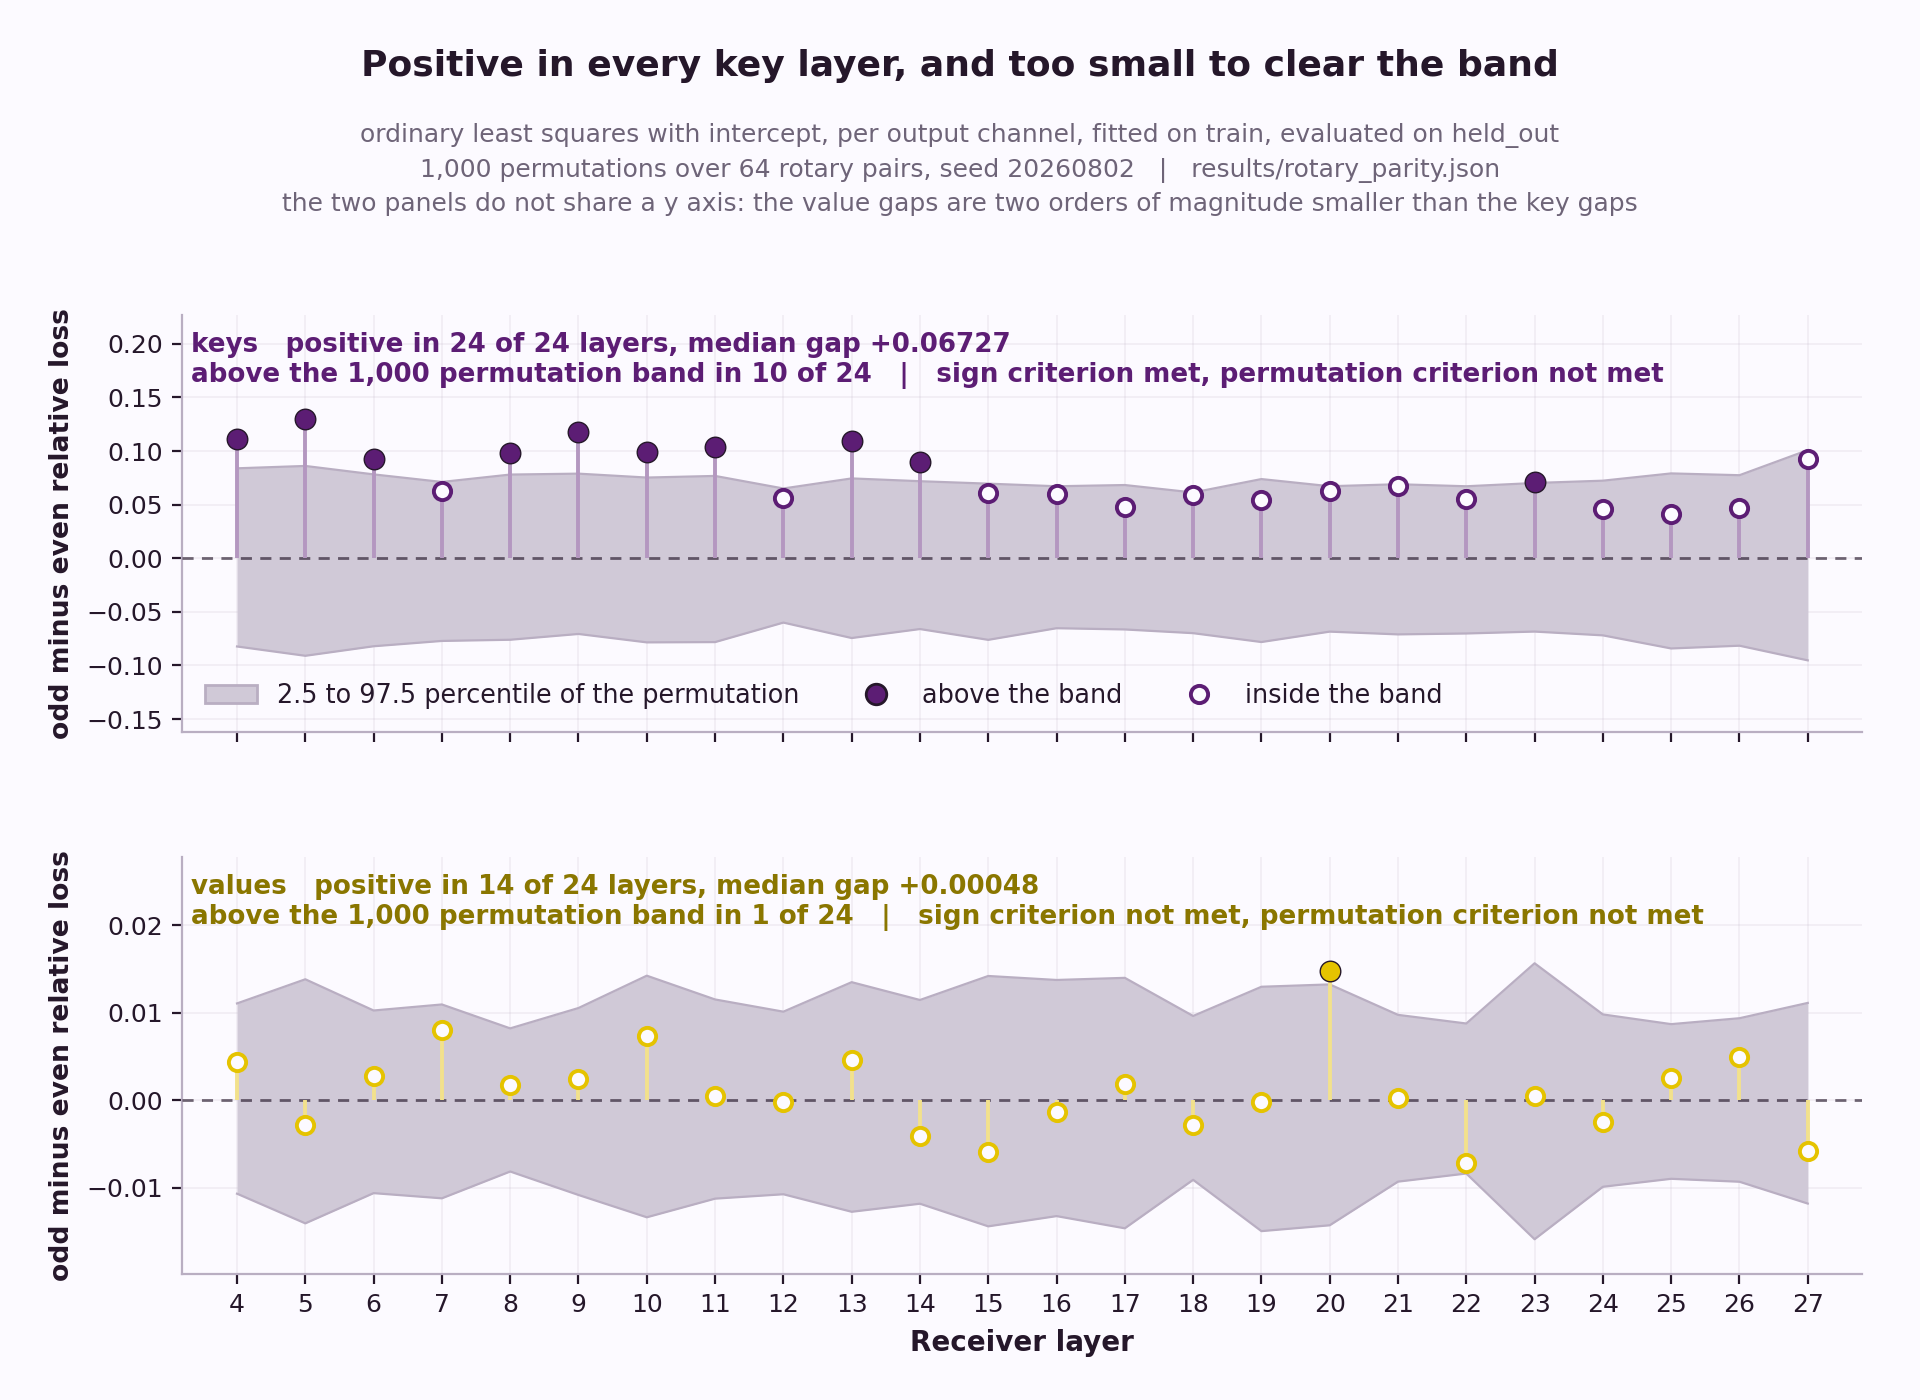

In [12]:
"""Probe: does the key cache split along the Sharer's rotary ladder.

Reads results/rotary_parity.json.

The Sharer's rotary frequencies nest inside the Receiver's at stride two, so
half the rotation a Receiver key needs is physically present in a transferred
key and half is a frequency the Sharer never uses. If that matters, the
Receiver channels whose rotary pair index is odd should be harder to predict
than the even ones.

The finding this probe returns is a conjunction: consistent in sign across
every layer, and too small to clear the band a permutation over rotary pairs
produces. A column of 24 numbers cannot carry a conjunction. A strip with the
band drawn behind it can, which is the only reason this is a figure.

Self-contained: run the whole cell. Writes assets/c2c_rotary_parity.png and
displays it inline.
"""

import json
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

PARITY_PATH = os.path.join(_THIS_DIR, "results", "rotary_parity.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_rotary_parity.png")

DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"
GOLD_INK = "#8A7600"

KIND_COLOURS = {"keys": PRIMARY, "values": SECONDARY}
INK = {"keys": PRIMARY, "values": GOLD_INK}


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(path: str = PARITY_PATH) -> dict:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/probe_rotary_parity.py first")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def build_rotary_parity(probe: dict, output_path: str = OUTPUT_PATH) -> dict:
    method = probe["method"]
    verdict = probe["verdict"]

    fig, axes = plt.subplots(2, 1, figsize=(9.6, 7.0), sharex=True,
                             facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.775, bottom=0.09, left=0.095, right=0.97, hspace=0.30)

    for ax, kind in zip(axes, ("keys", "values")):
        records = sorted((r for r in probe["per_layer"] if r["kind"] == kind),
                         key=lambda r: r["target_layer"])
        layers = np.array([r["target_layer"] for r in records])
        gaps = np.array([r["gap_equal_weight"] for r in records])
        band_low = np.array([r["permutation_percentile_2_5"] for r in records])
        band_high = np.array([r["permutation_percentile_97_5"] for r in records])
        above = np.array([bool(r["above_permutation_97_5"]) for r in records])

        colour = KIND_COLOURS[kind]
        ax.set_facecolor(BG_COLOR)

        ax.fill_between(layers, band_low, band_high,
                        color=_mix(MUTED, BG_COLOR, 0.35), zorder=1,
                        linewidth=0)
        ax.plot(layers, band_high, color=MUTED, linewidth=0.8, zorder=2)
        ax.plot(layers, band_low, color=MUTED, linewidth=0.8, zorder=2)
        ax.axhline(0.0, color=TEXT_COLOR, linewidth=1.0, linestyle=(0, (4, 3)),
                   alpha=0.65, zorder=3)

        ax.vlines(layers, 0.0, gaps, color=_mix(colour, BG_COLOR, 0.55),
                  linewidth=1.4, zorder=4)
        ax.plot(layers[~above], gaps[~above], linestyle="none", marker="o",
                markersize=6.2, markerfacecolor=BG_COLOR, markeredgecolor=colour,
                markeredgewidth=1.4, zorder=6)
        ax.plot(layers[above], gaps[above], linestyle="none", marker="o",
                markersize=7.4, markerfacecolor=colour,
                markeredgecolor=TEXT_COLOR, markeredgewidth=0.5, zorder=6)

        v = verdict[kind]
        ax.text(0.005, 0.96,
                f"{kind}   positive in {v['n_positive']} of {v['n_layers']} layers, "
                f"median gap {v['median_gap']:+.5f}\n"
                f"above the {method['permutations']:,} permutation band in "
                f"{v['n_above_permutation']} of {v['n_layers']}   |   "
                f"sign criterion {'met' if v['meets_sign_criterion'] else 'not met'}, "
                f"permutation criterion "
                f"{'met' if v['meets_permutation_criterion'] else 'not met'}",
                transform=ax.transAxes, ha="left", va="top", fontsize=9.4,
                color=INK[kind], fontweight="bold")

        ax.set_ylabel("odd minus even relative loss", fontsize=9.6,
                      fontweight="bold", color=TEXT_COLOR)
        ax.set_xlim(layers.min() - 0.8, layers.max() + 0.8)
        span = max(abs(gaps).max(), abs(band_high).max(), abs(band_low).max())
        ax.set_ylim(-span * 1.25, span * 1.75)
        ax.grid(True, color=MUTED, alpha=0.18, linewidth=0.6)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TEXT_COLOR, labelsize=9)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        for spine in ("left", "bottom"):
            ax.spines[spine].set_color(MUTED)

    axes[-1].set_xlabel("Receiver layer", fontsize=10, fontweight="bold",
                        color=TEXT_COLOR)
    axes[-1].set_xticks(sorted({r["target_layer"] for r in probe["per_layer"]}))

    legend = axes[0].legend(
        handles=[
            Patch(facecolor=_mix(MUTED, BG_COLOR, 0.35), edgecolor=MUTED,
                  label="2.5 to 97.5 percentile of the permutation"),
            Line2D([], [], linestyle="none", marker="o", markersize=7.4,
                   markerfacecolor=PRIMARY, markeredgecolor=TEXT_COLOR,
                   label="above the band"),
            Line2D([], [], linestyle="none", marker="o", markersize=6.2,
                   markerfacecolor=BG_COLOR, markeredgecolor=PRIMARY,
                   markeredgewidth=1.4, label="inside the band"),
        ],
        loc="lower left", frameon=False, fontsize=9.2, ncol=3,
    )
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)

    fig.suptitle("Positive in every key layer, and too small to clear the band",
                 color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.965)
    fig.text(0.5, 0.912,
             f"{method['estimator']}, fitted on {method['fit_split']}, "
             f"evaluated on {method['eval_split']}\n"
             f"{method['permutations']:,} permutations over "
             f"{method['n_rotary_pairs']} rotary pairs, seed "
             f"{method['permutation_seed']}   |   results/rotary_parity.json\n"
             "the two panels do not share a y axis: the value gaps are two orders "
             "of magnitude smaller than the key gaps",
             ha="center", va="top", fontsize=9.0, color="#6E6478", linespacing=1.5)

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return verdict


def main() -> None:
    probe = load()
    verdict = build_rotary_parity(probe)
    for kind in ("keys", "values"):
        v = verdict[kind]
        print(f"{kind}: positive {v['n_positive']}/{v['n_layers']}, "
              f"median gap {v['median_gap']:+.5f}, "
              f"above band {v['n_above_permutation']}/{v['n_layers']}, "
              f"sign {v['meets_sign_criterion']}, "
              f"permutation {v['meets_permutation_criterion']}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

keys: wikitext 0.4761 -> MMLU 0.6944, at or above the null at layers []
values: wikitext 0.6963 -> MMLU 0.9162, at or above the null at layers [13, 14, 23, 27]
-> /home/claude/repo/assets/c2c_distribution_shift.png


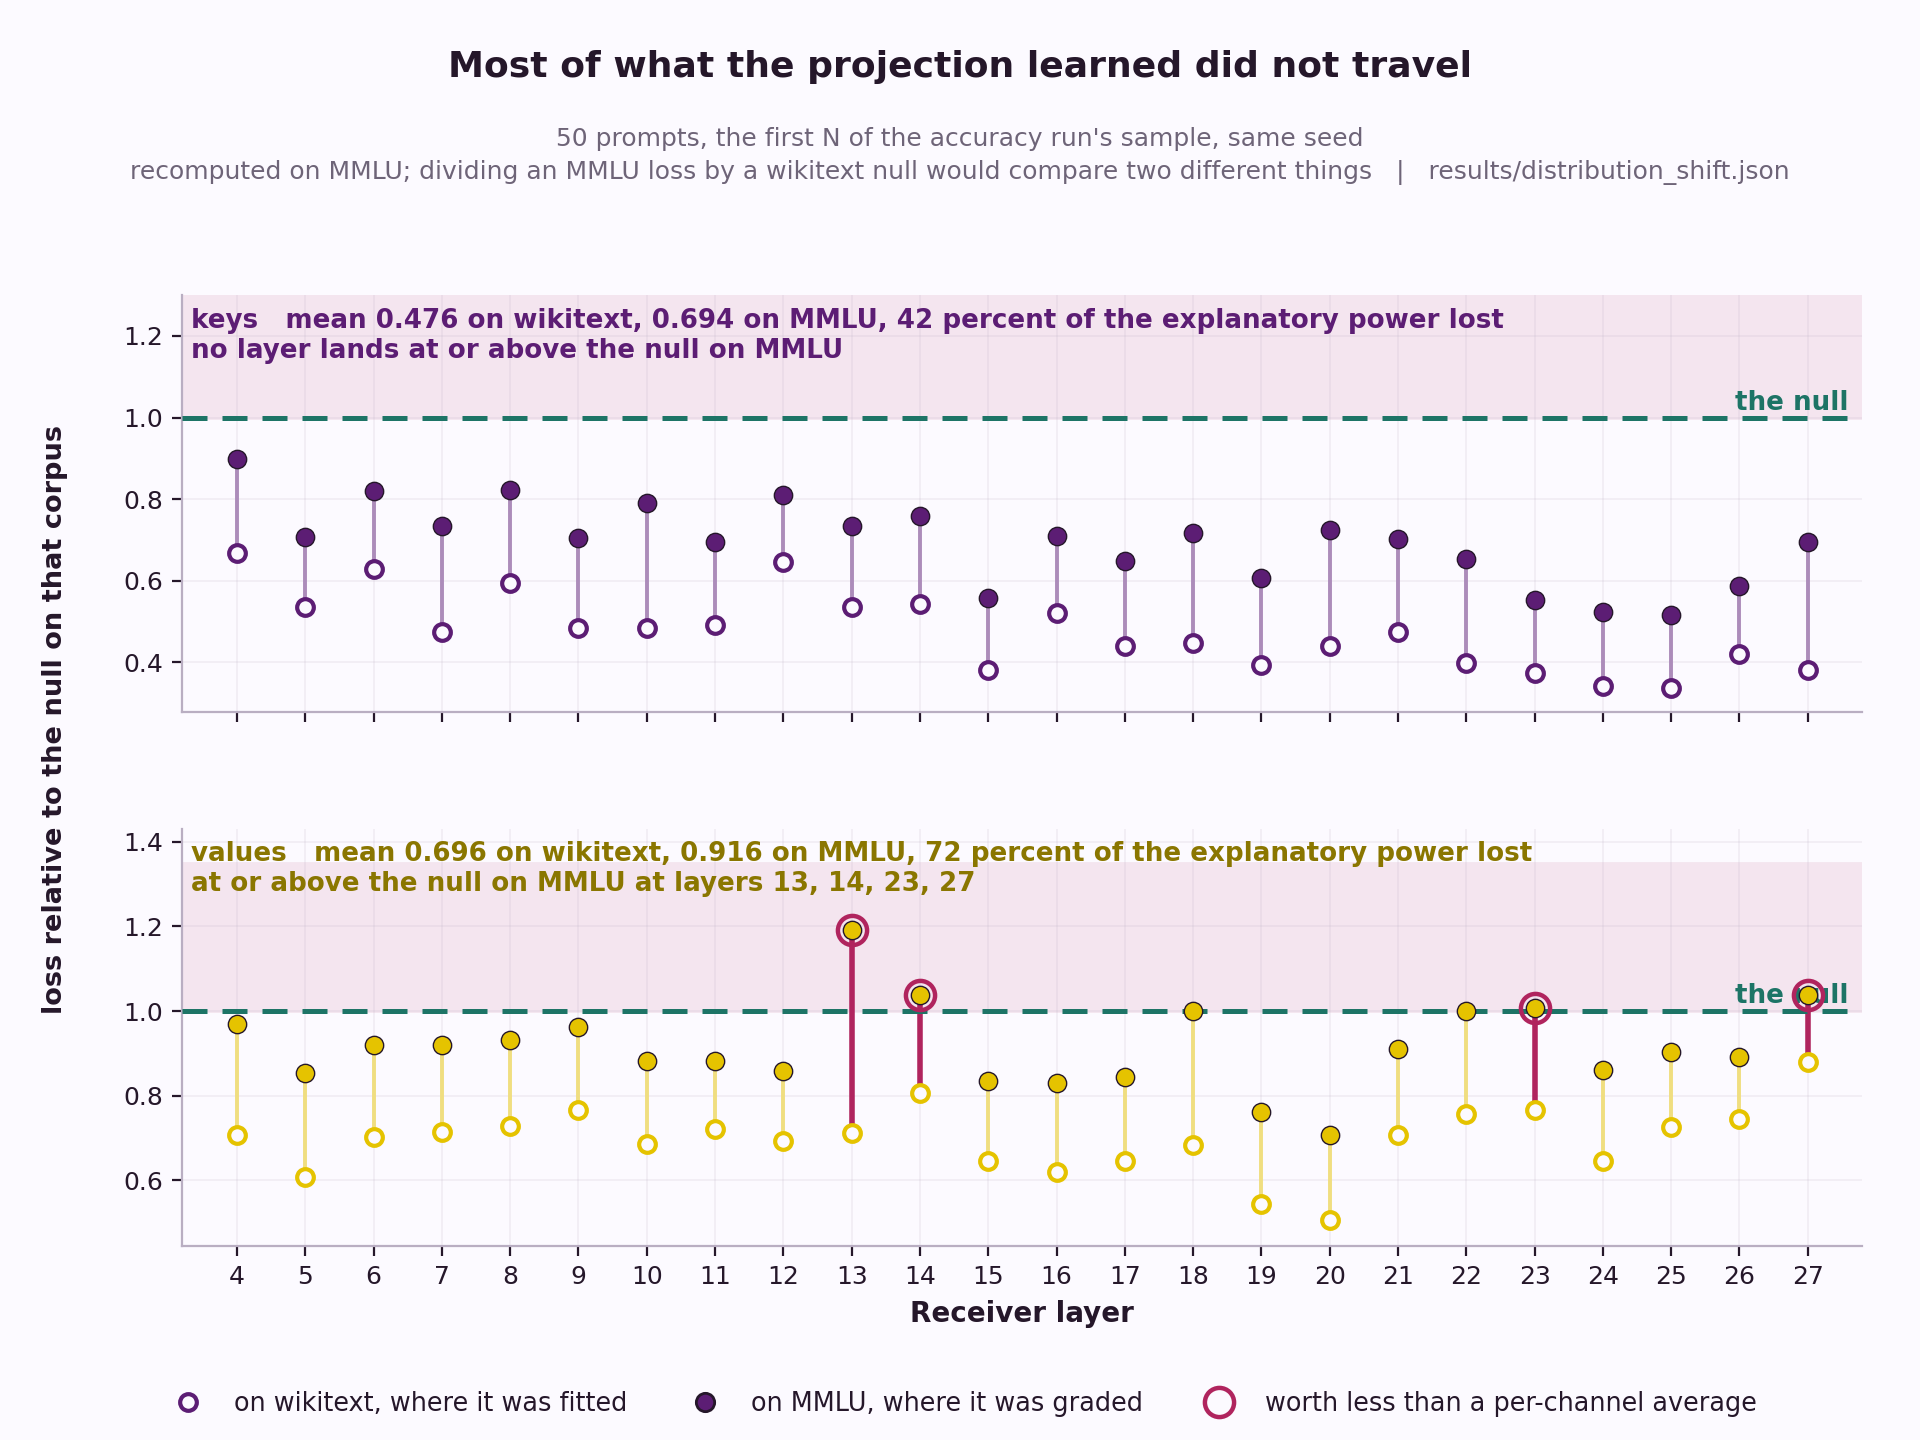

In [13]:
"""Probe: does a projection fitted on wikitext carry to MMLU.

Reads results/distribution_shift.json.

Each layer contributes one segment: where the trained projection stood on the
corpus it was fitted on, and where the same projection stands on the corpus
the accuracy run actually scored. The segment is the quantity of interest,
which is why the two ends are drawn joined rather than as two series.

The null is drawn at 1.0 in both panels rather than described in a caption,
because the layers that land at or above it are the finding: at those layers
the trained map is worth less than a per-channel average. The null is
recomputed on the grading corpus. Dividing an MMLU loss by a wikitext null
would compare two different things and the ratio would still look like a
result.

Self-contained: run the whole cell. Writes assets/c2c_distribution_shift.png
and displays it inline.
"""

import json
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

SHIFT_PATH = os.path.join(_THIS_DIR, "results", "distribution_shift.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_distribution_shift.png")

DPI = 200

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
QUATERNARY = "#B0245E"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"
GOLD_INK = "#8A7600"

KIND_COLOURS = {"keys": PRIMARY, "values": SECONDARY}
INK = {"keys": PRIMARY, "values": GOLD_INK}


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(path: str = SHIFT_PATH) -> dict:
    if not os.path.exists(path):
        raise SystemExit(f"missing {path}; run scripts/probe_distribution_shift.py first")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def build_distribution_shift(probe: dict, output_path: str = OUTPUT_PATH) -> dict:
    summary = probe["summary"]
    method = probe["method"]

    fig, axes = plt.subplots(2, 1, figsize=(9.6, 7.2), sharex=True,
                             facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.795, bottom=0.135, left=0.095, right=0.97, hspace=0.28)

    for ax, kind in zip(axes, ("keys", "values")):
        records = sorted((r for r in probe["per_layer"] if r["kind"] == kind),
                         key=lambda r: r["target_layer"])
        layers = np.array([r["target_layer"] for r in records])
        on_wikitext = np.array([r["relative_on_wikitext"] for r in records])
        on_mmlu = np.array([r["relative_projected"] for r in records])
        at_or_above = set(summary[kind]["layers_at_or_above_null_on_mmlu"])

        colour = KIND_COLOURS[kind]
        ax.set_facecolor(BG_COLOR)

        ax.axhspan(1.0, 1.35, color=_mix(QUATERNARY, BG_COLOR, 0.90), zorder=0)
        ax.axhline(1.0, color=TERTIARY, linewidth=1.8, linestyle=(0, (5, 3)),
                   zorder=4)
        ax.text(layers.max() + 0.6, 1.005, "the null", ha="right", va="bottom",
                fontsize=9.4, color=TERTIARY, fontweight="bold")

        for layer, low, high in zip(layers, on_wikitext, on_mmlu):
            ax.plot([layer, layer], [low, high],
                    color=QUATERNARY if layer in at_or_above
                    else _mix(colour, BG_COLOR, 0.50),
                    linewidth=2.0 if layer in at_or_above else 1.4, zorder=3)

        ax.plot(layers, on_wikitext, linestyle="none", marker="o", markersize=6.0,
                markerfacecolor=BG_COLOR, markeredgecolor=colour,
                markeredgewidth=1.5, zorder=6)
        ax.plot(layers, on_mmlu, linestyle="none", marker="o", markersize=6.6,
                markerfacecolor=colour, markeredgecolor=TEXT_COLOR,
                markeredgewidth=0.5, zorder=6)
        if at_or_above:
            mask = np.array([layer in at_or_above for layer in layers])
            ax.plot(layers[mask], on_mmlu[mask], linestyle="none", marker="o",
                    markersize=10.5, markerfacecolor="none",
                    markeredgecolor=QUATERNARY, markeredgewidth=1.6, zorder=7)

        s = summary[kind]
        lost = (s["mean_relative_on_mmlu"] - s["mean_relative_on_wikitext"]) / \
               (1.0 - s["mean_relative_on_wikitext"])
        above = s["layers_at_or_above_null_on_mmlu"]
        ax.text(0.005, 0.97,
                f"{kind}   mean {s['mean_relative_on_wikitext']:.3f} on wikitext, "
                f"{s['mean_relative_on_mmlu']:.3f} on MMLU, "
                f"{lost * 100:.0f} percent of the explanatory power lost\n"
                + (f"at or above the null on MMLU at layers "
                   f"{', '.join(str(x) for x in above)}"
                   if above else "no layer lands at or above the null on MMLU"),
                transform=ax.transAxes, ha="left", va="top", fontsize=9.4,
                color=INK[kind], fontweight="bold")

        ax.set_xlim(layers.min() - 0.8, layers.max() + 0.8)
        ax.set_ylim(min(on_wikitext.min(), on_mmlu.min()) - 0.06,
                    max(1.30, float(on_mmlu.max()) + 0.24))
        ax.grid(True, color=MUTED, alpha=0.18, linewidth=0.6)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TEXT_COLOR, labelsize=9)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        for spine in ("left", "bottom"):
            ax.spines[spine].set_color(MUTED)

    axes[-1].set_xlabel("Receiver layer", fontsize=10, fontweight="bold",
                        color=TEXT_COLOR)
    axes[-1].set_xticks(sorted({r["target_layer"] for r in probe["per_layer"]}))

    legend = fig.legend(
        handles=[
            Line2D([], [], linestyle="none", marker="o", markersize=6.0,
                   markerfacecolor=BG_COLOR, markeredgecolor=PRIMARY,
                   markeredgewidth=1.5, label="on wikitext, where it was fitted"),
            Line2D([], [], linestyle="none", marker="o", markersize=6.6,
                   markerfacecolor=PRIMARY, markeredgecolor=TEXT_COLOR,
                   label="on MMLU, where it was graded"),
            Line2D([], [], linestyle="none", marker="o", markersize=10.5,
                   markerfacecolor="none", markeredgecolor=QUATERNARY,
                   markeredgewidth=1.6, label="worth less than a per-channel average"),
        ],
        loc="lower center", frameon=False, fontsize=9.2, ncol=3,
        bbox_to_anchor=(0.5, 0.0),
    )
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)

    fig.supylabel("loss relative to the null on that corpus", fontsize=9.8,
                  fontweight="bold", color=TEXT_COLOR, x=0.022)
    fig.suptitle("Most of what the projection learned did not travel",
                 color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.965)
    fig.text(0.5, 0.912,
             f"{method['n_prompts']} prompts, {method['prompts']}\n"
             f"{method['null']}   |   results/distribution_shift.json",
             ha="center", va="top", fontsize=9.0, color="#6E6478", linespacing=1.5)

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return summary


def main() -> None:
    probe = load()
    summary = build_distribution_shift(probe)
    for kind in ("keys", "values"):
        s = summary[kind]
        print(f"{kind}: wikitext {s['mean_relative_on_wikitext']:.4f} -> "
              f"MMLU {s['mean_relative_on_mmlu']:.4f}, at or above the null at "
              f"layers {s['layers_at_or_above_null_on_mmlu']}")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

fused: total -0.51663 = four-way -0.12342 + letter mass -0.39321, residue 0.0
    four-way interval -0.1234 [-0.2766, +0.0217] on 64 questions
replace: total -0.20000 = four-way +0.21973 + letter mass -0.41973, residue 0.0
    four-way interval +0.2197 [-0.1412, +0.5395] on 64 questions
-> /home/claude/repo/assets/c2c_loss_decomposition.png


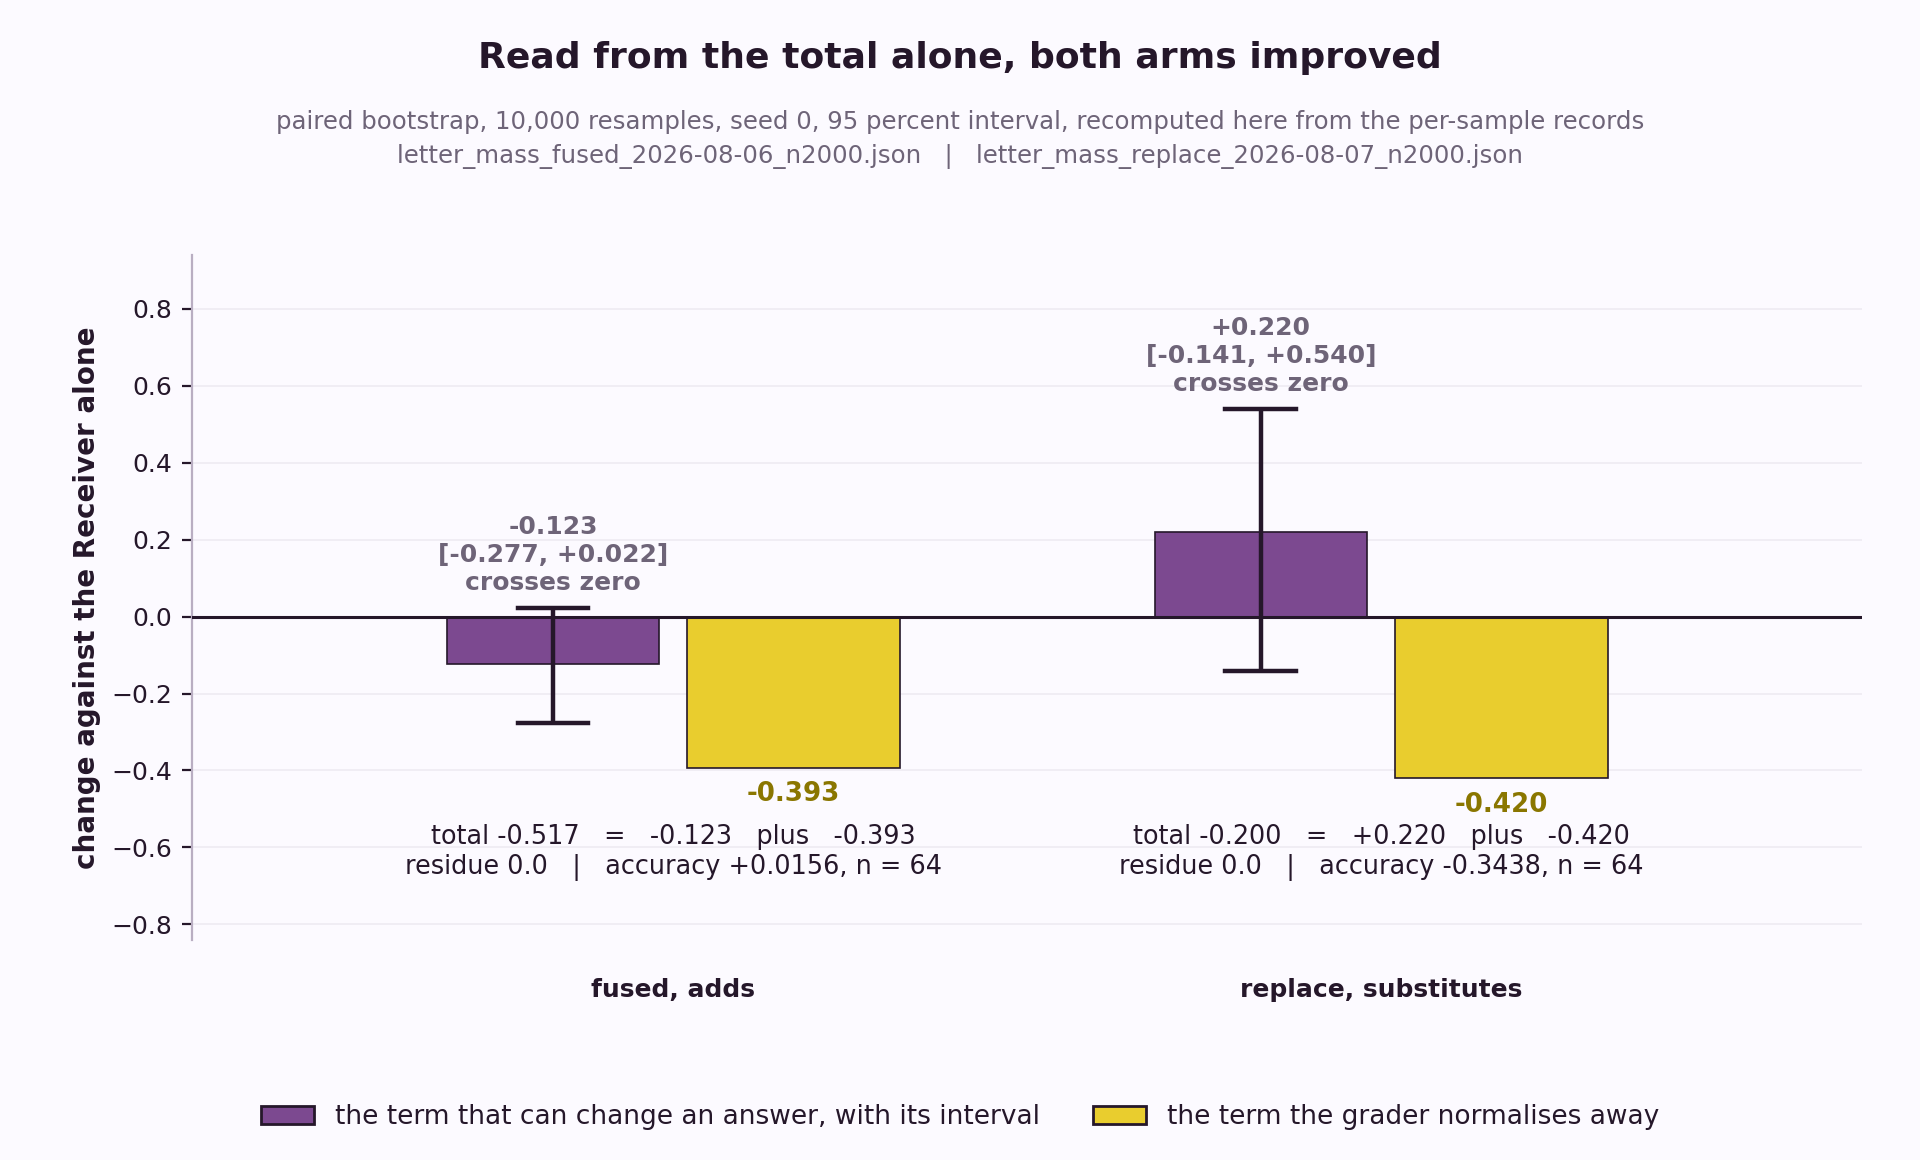

In [14]:
"""Probe: where each arm's loss drop went.

Reads every results/letter_mass_<mode>_<date>_n<N>.json.

The objective is next-token prediction and the grade is an argmax over four
option letters. A loss can fall because the model became better at choosing
between the letters, or because it became more certain the answer is a letter
at all without changing which one wins. With `M` the probability mass on the
four option letters and `c` the correct one,

    -log p(c) = -log( p(c) / M ) + -log M

and the first term is the only part that can change an answer. The two terms
sum to the total exactly, and the residue recorded in each file is printed
into the figure rather than trusted silently.

The terms are drawn adjacent rather than stacked. One of them moves the other
way in the replacement arm, and a stack cannot show a term with the opposite
sign to the one beside it.

The interval on the term that can change an answer is recomputed here from
the paired per-sample records, with the seed written above, rather than read
from a summary. On both arms it crosses zero, and the figure says so.

Self-contained: run the whole cell. Writes assets/c2c_loss_decomposition.png
and displays it inline.
"""

import glob
import json
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)

RESULTS_DIR = os.path.join(_THIS_DIR, "results")
LETTER_MASS_GLOB = os.path.join(RESULTS_DIR, "letter_mass_*_n*.json")
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "c2c_loss_decomposition.png")

N_RESAMPLES = 10000
CI_LEVEL = 0.95
SEED = 0
DPI = 200

MODE_LABELS = {"fused": "fused, adds", "replace": "replace, substitutes"}

# === BRAND PALETTE ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TERTIARY = "#1D7466"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"
MUTED = "#B9AEC2"
GOLD_INK = "#8A7600"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def load(pattern: str = LETTER_MASS_GLOB) -> list[tuple[dict, str]]:
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise SystemExit(f"no file matching {pattern}; run scripts/probe_letter_mass.py first")
    out = []
    for path in paths:
        with open(path, encoding="utf-8") as f:
            out.append((json.load(f), path))
    out.sort(key=lambda item: item[0]["mode"] != "fused")
    return out


def _paired(probe: dict, term: str) -> tuple[np.ndarray, np.ndarray]:
    """Align the baseline and the arm by question index, not by list order."""
    records = probe["records"]
    baseline = {r["index"]: r[term] for r in records["baseline"]}
    # The replacement arm stores its own records under the same key as the
    # fused arm. The mode field is what distinguishes them, not this name.
    arm = {r["index"]: r[term] for r in records["fused"]}
    shared = sorted(set(baseline) & set(arm))
    return (np.array([baseline[i] for i in shared], dtype=float),
            np.array([arm[i] for i in shared], dtype=float))


def _bootstrap(before: np.ndarray, after: np.ndarray, seed: int = SEED) -> tuple:
    rng = np.random.default_rng(seed)
    n = len(before)
    idx = rng.integers(0, n, size=(N_RESAMPLES, n))
    draws = after[idx].mean(axis=1) - before[idx].mean(axis=1)
    alpha = (1.0 - CI_LEVEL) / 2.0
    low, high = np.quantile(draws, [alpha, 1.0 - alpha])
    return float(after.mean() - before.mean()), float(low), float(high)


def build_loss_decomposition(probes: list[tuple[dict, str]],
                             output_path: str = OUTPUT_PATH) -> list[dict]:
    rows = []
    for probe, path in probes:
        before, after = _paired(probe, "four_way")
        point, low, high = _bootstrap(before, after)
        rows.append({
            "mode": probe["mode"],
            "source": os.path.basename(path),
            "n": len(before),
            "four_way": probe["delta"]["four_way"],
            "letter_mass": probe["delta"]["letter_mass"],
            "full": probe["delta"]["full"],
            "residue": probe["decomposition_residue"],
            "accuracy": probe["delta"]["accuracy"],
            "interval": (point, low, high),
        })

    fig, ax = plt.subplots(figsize=(9.6, 5.8), facecolor=BG_COLOR)
    fig.subplots_adjust(top=0.78, bottom=0.19, left=0.10, right=0.97)
    ax.set_facecolor(BG_COLOR)

    width = 0.30
    positions = np.arange(len(rows))

    ax.axhline(0.0, color=TEXT_COLOR, linewidth=1.1, zorder=4)

    bottom_text_y = min(min(r["letter_mass"], r["interval"][1]) for r in rows) - 0.12

    for i, row in enumerate(rows):
        point, low, high = row["interval"]
        ax.bar(i - width / 2 - 0.02, row["four_way"], width=width,
               facecolor=_mix(PRIMARY, BG_COLOR, 0.20), edgecolor=TEXT_COLOR,
               linewidth=0.6, zorder=3)
        ax.bar(i + width / 2 + 0.02, row["letter_mass"], width=width,
               facecolor=_mix(SECONDARY, BG_COLOR, 0.18), edgecolor=TEXT_COLOR,
               linewidth=0.6, zorder=3)

        ax.plot([i - width / 2 - 0.02] * 2, [low, high], color=TEXT_COLOR,
                linewidth=1.6, zorder=6, solid_capstyle="butt")
        for edge in (low, high):
            ax.plot([i - width / 2 - 0.02 - 0.05, i - width / 2 - 0.02 + 0.05],
                    [edge, edge], color=TEXT_COLOR, linewidth=1.6, zorder=6)

        crosses = low < 0.0 < high
        ax.text(i - width / 2 - 0.02, high + 0.035,
                f"{point:+.3f}\n[{low:+.3f}, {high:+.3f}]\n"
                f"{'crosses zero' if crosses else 'excludes zero'}",
                ha="center", va="bottom", fontsize=9.0,
                color="#6E6478" if crosses else GOLD_INK, fontweight="bold")
        ax.text(i + width / 2 + 0.02,
                row["letter_mass"] - 0.035 if row["letter_mass"] < 0
                else row["letter_mass"] + 0.035,
                f"{row['letter_mass']:+.3f}",
                ha="center", va="top" if row["letter_mass"] < 0 else "bottom",
                fontsize=9.4, color=GOLD_INK, fontweight="bold")

        ax.text(i, bottom_text_y,
                f"total {row['full']:+.3f}   =   {row['four_way']:+.3f}   plus   "
                f"{row['letter_mass']:+.3f}\n"
                f"residue {row['residue']:.1f}   |   accuracy "
                f"{row['accuracy']:+.4f}, n = {row['n']}",
                ha="center", va="top", fontsize=9.2, color=TEXT_COLOR)

    ax.set_xticks(positions)
    ax.set_xticklabels([MODE_LABELS.get(r["mode"], r["mode"]) for r in rows],
                       fontsize=11.5, color=TEXT_COLOR, fontweight="bold")
    ax.set_ylabel("change against the Receiver alone", fontsize=10,
                  fontweight="bold", color=TEXT_COLOR)
    ax.set_xlim(-0.68, len(rows) - 0.32)
    top = max(r["interval"][2] for r in rows)
    ax.set_ylim(bottom_text_y - 0.30, top + 0.40)
    ax.grid(True, axis="y", color=MUTED, alpha=0.20, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.tick_params(axis="x", length=0, pad=14)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED)
    ax.spines["bottom"].set_visible(False)

    legend = fig.legend(
        handles=[
            Patch(facecolor=_mix(PRIMARY, BG_COLOR, 0.20), edgecolor=TEXT_COLOR,
                  label="the term that can change an answer, with its interval"),
            Patch(facecolor=_mix(SECONDARY, BG_COLOR, 0.18), edgecolor=TEXT_COLOR,
                  label="the term the grader normalises away"),
        ],
        loc="lower center", bbox_to_anchor=(0.5, 0.005), frameon=False,
        fontsize=9.5, ncol=2,
    )
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)

    fig.suptitle("Read from the total alone, both arms improved",
                 color=TEXT_COLOR, fontweight="bold", fontsize=13, y=0.965)
    fig.text(0.5, 0.905,
             f"paired bootstrap, {N_RESAMPLES:,} resamples, seed {SEED}, "
             f"{int(CI_LEVEL * 100)} percent interval, recomputed here from the "
             "per-sample records\n"
             + "   |   ".join(row["source"] for row in rows),
             ha="center", va="top", fontsize=8.8, color="#6E6478", linespacing=1.5)

    fig.savefig(output_path, dpi=DPI, facecolor=BG_COLOR)
    plt.close(fig)
    return rows


def main() -> None:
    probes = load()
    rows = build_loss_decomposition(probes)
    for row in rows:
        point, low, high = row["interval"]
        print(f"{row['mode']}: total {row['full']:+.5f} = four-way "
              f"{row['four_way']:+.5f} + letter mass {row['letter_mass']:+.5f}, "
              f"residue {row['residue']}")
        print(f"    four-way interval {point:+.4f} [{low:+.4f}, {high:+.4f}] "
              f"on {row['n']} questions")
    print(f"-> {OUTPUT_PATH}")
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()